# Probabilistic Flood Mapping
## Uncertainty Quantification for Flood Modelling (UQ4FM) project, University of Edinburgh
### Nina Fischer, Adil Siripatana, Amy Wilson, Lindsay Beevers

This notebook demonstrates a case study for probabilistic flood mapping using surrogate modelling, applied to the town of Inverurie, Scotland, which sits at the confluence of the River Don and River Urie and has a long history of severe fluvial flooding. The most significant recent event occurred in January 2016. For details on the methods, we refer to:

Siripatana, A., Wilson, A. L., & Beevers, L. (2025). Uncertainty quantification for multi-input fluvial flood inundation using GPR- and PCE-based surrogates. *Water Resources Research*, 61, e2024WR039668. <https://doi.org/10.1029/2024WR039668>

For the interactive flood map, see [here](https://nina3211.github.io/case_study_inverurie/)

## Overview

Traditional probabilistic flood modelling, such as Full Monte Carlo (FMC), requires running a hydraulic model hundreds or thousands of times to propagate input uncertainty through to inundation predictions. This is computationally prohibitive for high-resolution 2D models. This notebook implements a surrogate-based approach that replaces the expensive hydraulic model with a fast surrogate model, trained on a small set of model runs.

We focus on uncertainty in the **inflow boundary conditions**: the peak discharge at each upstream tributary and the timing lag between them. These inflow uncertainties have been shown to have a larger influence on flood inundation predictions than model parameter uncertainty.

The surrogate used here is **PCK (Polynomial Chaos Kriging)**, which combines a Polynomial Chaos Expansion (PCE) trend with a Gaussian Process Regression (GPR) residual. PCE provides a systematic way to approximate the model response surface using orthogonal polynomials, while the GPR component captures residual non-linear patterns and provides a built-in variance estimate. To handle the high dimensionality of the spatial flood maps, **POD (Proper Orthogonal Decomposition)** via SVD is first used to compress each map into a small number of dominant modes; a separate PCK model is then fitted to each modal coefficient.

## Workflow

**Step 0 — Calibrate the Flood Model**  
Calibrate the hydraulic model (here: LISFLOOD-FP) against observed flood events. Verify that the model accurately reproduces known inundation extents and water depths before proceeding.

---

### Stage 1: Inflow Analysis

**Step 1a — Analyse AMAX Data**  
Fit a GEV distribution to the Annual Maximum (AMAX) flow series for each tributary. Derive 95% bootstrap confidence bounds on peak inflows at the return period of interest. These bounds define the input uncertainty space.

**Step 1b — Analyse Lag**  
Characterise the timing difference between peak flows at each tributary pair from observed time series data. A Normal distribution is fitted to the empirical lag distribution to represent lag uncertainty.

---

### Stage 2: Surrogate Model Construction

**Step 2 — Generate Training Input Set**  
Use Sobol quasi-random sampling to generate space-filling combinations of peak inflows and lag.

**Step 3 — Construct Synthetic Hydrographs**  
Convert each sampled peak inflow into a full hydrograph by scaling a normalised unit hydrograph derived from a historical flood event. Apply the sampled lag by shifting the non-reference tributary hydrograph in time using cubic spline interpolation.

**Step 4 — Run the Hydraulic Model**  
Run LISFLOOD-FP for each training hydrograph. Extract the maximum inundation depth map for each simulation.

**Step 5 — Train the Surrogate Model**  
Compress flood maps using POD, then fit a PCK surrogate to map sampled inputs to POD coefficients.

**Step 6 — Validate the Surrogate**  
Evaluate surrogate performance on a held-out test set using spatial error metrics (R², MAE, Bias).

---

### Stage 3: Probabilistic Flood Mapping

**Step 7 — Sample the Inflow Space**  
Generate a large Monte Carlo ensemble of equally likely peak inflow realisations consistent with the target return period.

**Step 8 — Predict Inundation Maps**  
Pass the ensemble through the trained surrogate to obtain predicted maximum inundation maps with uncertainty estimates.

**Step 9 — Generate Probabilistic Flood Maps**  
Aggregate ensemble predictions to produce probability-of-inundation maps and depth percentile maps.

---
# CONFIGURATION
**Edit this cell and the cell below before running anything else.**  
All other cells read from these settings — no other paths or names need changing.

In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# CONFIGURATION — edit this cell only
# ═══════════════════════════════════════════════════════════════════════════

# ── Site & analysis settings ────────────────────────────────────────────────
SITE_NAME     = "Inverurie"   # used in output folder names
RETURN_PERIOD = 30            # return period of interest (years)
N_SAMPLES     = 150           # number of training samples
SAMPLE_RULE   = "sobol"       # chaospy sampling rule
SAMPLE_SEED   = 23415           # random seed

# ── Tributaries ─────────────────────────────────────────────────────────────
# Add one dict per upstream boundary.
# Order must match the section order in your .bdy template file.
# Set "lag_reference": True on exactly ONE tributary — lags are measured from it.
TRIBUTARIES = [
    {
        "name":               "Don_at_Haughton",       # used in filenames/variables (no spaces)
        "label":              "Don at Haughton",        # used in plot titles
        "amax_file":          "Z:/inverurie_data/Inverurie_emulator_Inputs/Haughton_AMAX.xlsx",
        "amax_year_col":      "Year",                   # column name in AMAX file
        "amax_flow_col":      "Number",                 # column name in AMAX file
        "flow_file":          "Z:/inverurie_data/Inverurie_emulator_Inputs/SEPA_Inver_formatted/Haughton_15m_Q_All_formatted.csv",
        "flow_sep":           ";",                      # CSV separator
        "flow_timestamp_col": "Timestamp",
        "flow_value_col":     "Value",
        "bdy_section":        "upstream1",              # section name in .bdy file
        "lag_reference":      True,                     # lag measured FROM this tributary
    },
    {
        "name":               "Urie_at_Pitcaple",
        "label":              "Urie at Pitcaple",
        "amax_file":          "Z:/inverurie_data/Inverurie_emulator_Inputs/SEPA_AMAX_Pitcaple.xlsx",
        "amax_year_col":      "Year",
        "amax_flow_col":      "Number",
        "flow_file":          "Z:/inverurie_data/Inverurie_emulator_Inputs/SEPA_Inver_formatted/Pitcaple_15m_Q_All_formatted.csv",
        "flow_sep":           ";",
        "flow_timestamp_col": "Timestamp",
        "flow_value_col":     "Value",
        "bdy_section":        "upstream2",
        "lag_reference":      False,
    },
    # To add a third tributary, copy the block above and append it here.
]

# ── Input files ─────────────────────────────────────────────────────────────
BDY_TEMPLATE = "Z:/inverurie_data/Inverurie_emulator_Inputs/Inverurie_8Jan2016_5m_normalized_new.bdy"

# ── Flood model grid ────────────────────────────────────────────────────────
NROWS = 1000
NCOLS = 900

# ── Return periods computed in GEV analysis ──────────────────────────────────
RETURN_PERIODS_GEV = [2, 5, 10, 20, 30, 50, 100, 120, 200]

# ── Output folders (all created automatically) ───────────────────────────────
OUTPUT_BASE     = f"./{SITE_NAME}_outputs"
FIGURES_DIR     = f"{OUTPUT_BASE}/figures"
GEV_DIR         = f"{OUTPUT_BASE}/gev_results"
SAMPLES_DIR     = f"{OUTPUT_BASE}/training_data/samples"
BDY_SCALED_DIR  = f"{OUTPUT_BASE}/training_data/bdy_scaled"   # scaled, pre-lag
BDY_SHIFTED_DIR = f"{OUTPUT_BASE}/training_data/bdy_shifted"  # scaled + lag applied
FLOOD_MAPS_DIR  = f"{OUTPUT_BASE}/flood_maps"                 # LISFLOOD output .max files go here
PREDICTIONS_DIR = f"{OUTPUT_BASE}/predictions"

---
# Software Setup
Run once to install/check all required packages.

In [2]:
# Python imports and output folder creation
import os, csv, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import chaospy as cp
import gstools
import joblib
import pyproj
import matplotlib.lines as mlines
import multiprocessing as mp
from scipy.interpolate import splrep, splev
from scipy.linalg import svd
from scipy.signal import find_peaks
from scipy.stats import norm as scipy_norm
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D
from tqdm import tqdm
from pyproj import Transformer

warnings.filterwarnings('ignore')

# Create all output directories
for d in [FIGURES_DIR, GEV_DIR, SAMPLES_DIR, BDY_SCALED_DIR, BDY_SHIFTED_DIR,
          FLOOD_MAPS_DIR, PREDICTIONS_DIR]:
    os.makedirs(d, exist_ok=True)

# Derived config
N_TRIBUTARIES = len(TRIBUTARIES)
REF_IDX       = next(i for i, t in enumerate(TRIBUTARIES) if t["lag_reference"])
NON_REF_IDXS  = [i for i in range(N_TRIBUTARIES) if i != REF_IDX]
RET_IDX       = RETURN_PERIODS_GEV.index(RETURN_PERIOD)

print(f"Site:            {SITE_NAME}")
print(f"Tributaries:     {[t['label'] for t in TRIBUTARIES]}")
print(f"Lag reference:   {TRIBUTARIES[REF_IDX]['label']}")
print(f"Return period:   1-in-{RETURN_PERIOD} years")
print(f"Training samples: {N_SAMPLES}")
print(f"Output base:     {OUTPUT_BASE}")

Site:            Inverurie
Tributaries:     ['Don at Haughton', 'Urie at Pitcaple']
Lag reference:   Don at Haughton
Return period:   1-in-30 years
Training samples: 150
Output base:     ./Inverurie_outputs


In [3]:
%load_ext rpy2.ipython

In [4]:
%%R
# Install any missing R packages
packages <- c("readxl", "ggplot2", "extRemes", "gridExtra", "ggpubr", "withr")
for (pkg in packages) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    cat("Installing:", pkg, "\n")
    install.packages(pkg)
  } else {
    cat("Already installed:", pkg, "\n")
  }
}

Already installed: readxl 
Already installed: ggplot2 
Already installed: extRemes 
Already installed: gridExtra 
Already installed: ggpubr 
Already installed: withr 


---
# Stage 1: Inflow Analysis
## Step 1a: GEV Analysis of AMAX Data

The **Generalised Extreme Value (GEV)** distribution is fitted to the Annual Maximum (AMAX) flow series for each tributary using maximum likelihood estimation. 

95% confidence intervals on the GEV quantiles are derived using a **bootstrap method** (1000 resamples), as implemented in the `extRemes` R package. The lower and upper bounds at the return period of interest define the range of plausible peak inflows, which are used as the bounds of the Uniform input distributions in the subsequent sampling stage.

In [5]:
# Build R config strings from Python TRIBUTARIES list
# These are injected into R via rpy2 before running the GEV cell

import rpy2.robjects as ro

# Build R config strings from Python TRIBUTARIES list
import rpy2.robjects as ro

# Build R file_configs list string — no trailing comma after last item
r_file_configs_str = "file_configs <- list(\n"
for i, t in enumerate(TRIBUTARIES):
    path = t['amax_file'].replace('\\', '/')
    entry = (
        f"  list(path='{path}', label=\"{t['label']}\", "
        f"year_col=\"{t['amax_year_col']}\", flow_col=\"{t['amax_flow_col']}\")"
    )
    # Add comma after every entry except the last
    if i < len(TRIBUTARIES) - 1:
        entry += ","
    r_file_configs_str += entry + "\n"
r_file_configs_str += ")"

# Inject variables into R
ro.r(r_file_configs_str)
ro.r(f"return_periods <- c({', '.join(str(x) for x in RETURN_PERIODS_GEV)})")
ro.r(f"target_rp <- {RETURN_PERIOD}")
ro.r(f"output_dir <- '{GEV_DIR.replace(chr(92), '/')}/'")
ro.r(f"figures_dir <- '{FIGURES_DIR.replace(chr(92), '/')}/'")
ro.r(f"n_tribs <- {N_TRIBUTARIES}")

print("R config injected successfully")

R config injected successfully


[Don at Haughton] RP 10-yr  GEV: 222.76  Lower: 176.41  Upper: 276.79
[Don at Haughton] RP 30-yr  GEV: 291.61  Lower: 207.74  Upper: 422.82
[Don at Haughton] RP 100-yr  GEV: 376.22  Lower: 230.09  Upper: 698.67
[Don at Haughton] Results saved to: ./Inverurie_outputs/gev_results/gev_results_Don_at_Haughton.csv

[Urie at Pitcaple] RP 10-yr  GEV: 52.39  Lower: 38.55  Upper: 69.55
[Urie at Pitcaple] RP 30-yr  GEV: 72.91  Lower: 47.35  Upper: 112.47
[Urie at Pitcaple] RP 100-yr  GEV: 97.87  Lower: 54.38  Upper: 191.33
[Urie at Pitcaple] Results saved to: ./Inverurie_outputs/gev_results/gev_results_Urie_at_Pitcaple.csv



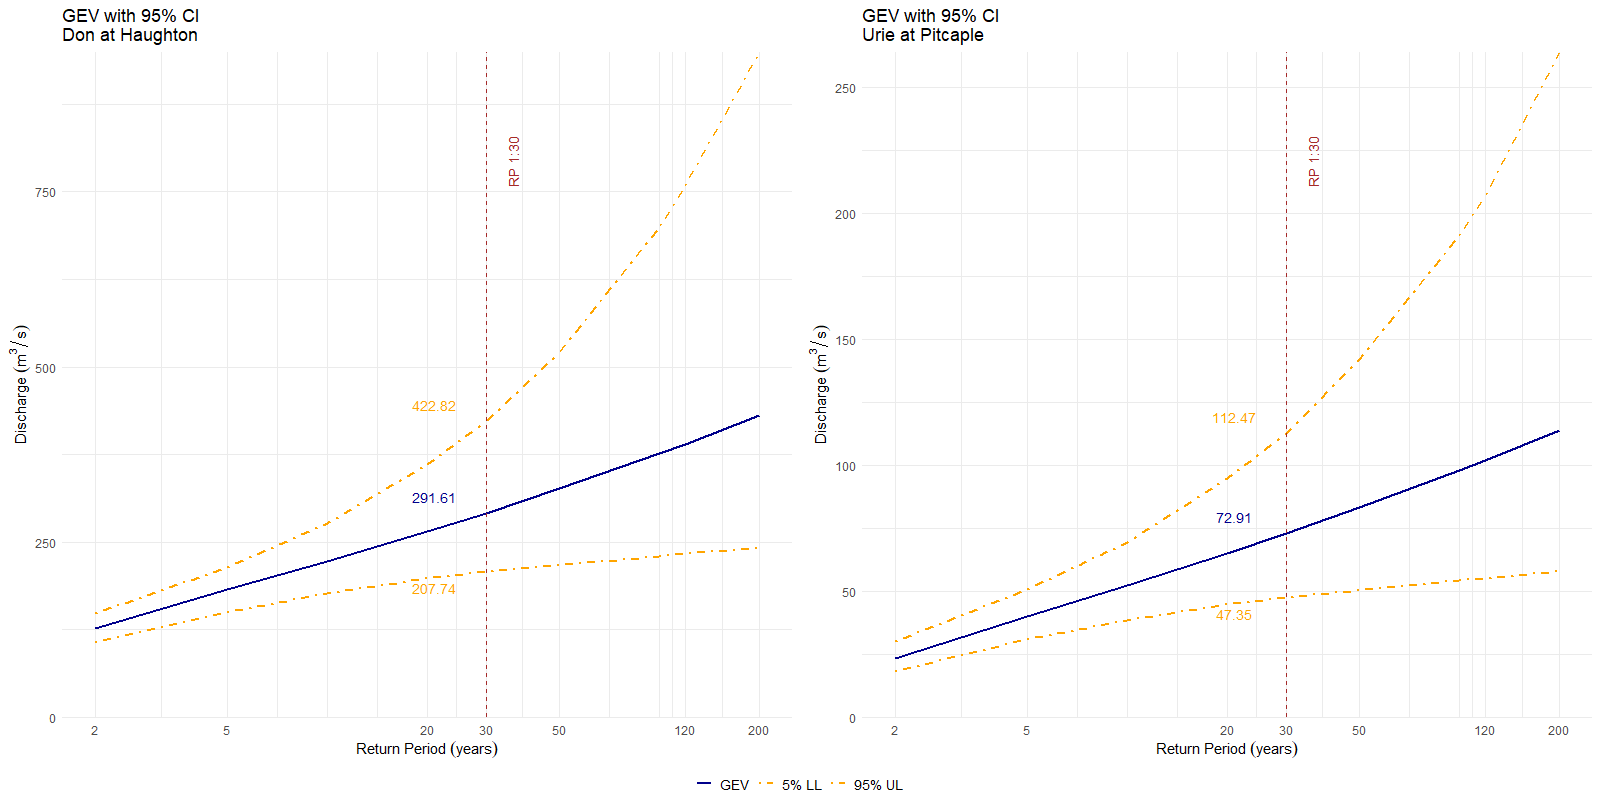

In [6]:
%%R -w 1600 -h 800 -u px

suppressWarnings(suppressPackageStartupMessages({
  library(readxl); library(ggplot2); library(extRemes); library(gridExtra); library(ggpubr)
}))

set.seed(123)

process_file <- function(cfg) {
  invisible(capture.output(
  data <- read_excel(cfg$path),
  type = "message"
    ))
  Qmax   <- data.frame(Year = data[[cfg$year_col]], Q = data[[cfg$flow_col]])
  fit    <- fevd(Qmax$Q, type = "GEV", verbose=FALSE)
  quants <- sapply(return_periods, function(rp) return.level(fit, return.period = rp))
    ci_res <- ci(fit, type="return.level", return.period=return_periods,
             method="boot", R=1000, verbose=FALSE)
  lower <- ci_res[, "2.5%"]
  upper <- ci_res[, "97.5%"]
  # Print key values
  for (rp in c(10, target_rp, 100)) {
    idx <- which(return_periods == rp)
    cat(sprintf("[%s] RP %d-yr  GEV: %.2f  Lower: %.2f  Upper: %.2f\n",
                cfg$label, rp, quants[idx], lower[idx], upper[idx]))
  }

  # Save results CSV
  out_csv <- paste0(output_dir, "gev_results_", gsub(" ", "_", cfg$label), ".csv")
  write.csv(data.frame(ReturnPeriod=return_periods, GEV_Quantile=quants,
                        Lower_Limit=lower, Upper_Limit=upper),
            file=out_csv, row.names=FALSE)
  cat(sprintf("[%s] Results saved to: %s\n\n", cfg$label, out_csv))

  # Store in global env for export to Python
  suffix <- gsub(" ", "_", cfg$label)
  assign(paste0("gev_lower_", suffix), lower, envir=.GlobalEnv)
  assign(paste0("gev_upper_", suffix), upper, envir=.GlobalEnv)
  # Build plot
  plot_data <- data.frame(
    ReturnPeriod = rep(return_periods, 3),
    Magnitude    = c(quants, lower, upper),
    Type         = rep(c("GEV", "Lower Limit", "Upper Limit"), each=length(return_periods))
  )
  y_max   <- max(plot_data$Magnitude)
  idx_rp  <- which(return_periods == target_rp)
  v <- list(gev=quants[idx_rp], lower=lower[idx_rp], upper=upper[idx_rp])

  p <- ggplot(plot_data, aes(x=ReturnPeriod, y=Magnitude, color=Type, linetype=Type)) +
    geom_line(linewidth=1) +
    scale_color_manual(values=c("darkblue","orange","orange"), labels=c("GEV","5% LL","95% UL")) +
    scale_linetype_manual(values=c("solid","dotdash","dotdash"), labels=c("GEV","5% LL","95% UL")) +
    labs(x=expression(Return~Period~(years)), y=expression(Discharge~(m^3/s)),
         title=paste0("GEV with 95% CI\n", cfg$label)) +
    theme_minimal(base_size = 15) +
    scale_x_continuous(trans = 'log10', breaks = return_periods,
                     labels = ifelse(return_periods == 10 | return_periods == 100, "", as.character(return_periods))) +  # Exclude axis labels for RP = 10 and 100
    scale_y_continuous(expand=c(0,0), limits=c(0,NA)) +
    theme(legend.title=element_blank(), legend.text = element_text(size = 14)) +
    geom_vline(xintercept=target_rp, linetype="dashed", color="brown") +
    annotate("text", x=target_rp*1.35, y=y_max*0.95,
             label=paste0("RP 1:",target_rp), vjust=-1, color="brown", angle=90, hjust=2, size = 5) +
    annotate("text", x=target_rp*0.7, y=v$gev,   label=round(v$gev,2),   vjust=-1, color="darkblue", size = 5) +
    annotate("text", x=target_rp*0.7, y=v$lower, label=round(v$lower,2), vjust=2,  color="orange", size = 5) +
    annotate("text", x=target_rp*0.7, y=v$upper, label=round(v$upper,2), vjust=-1, color="orange", size = 5)
  return(p)

}

plots <- lapply(file_configs, process_file)
GEV_plot <- ggpubr::ggarrange(plotlist = plots,
                              ncol = length(plots),
                              common.legend = TRUE,
                              legend = "bottom")
print(GEV_plot)

png("GEV_fit_out.png", width = 12, height = 6, units = "in", res = 150)
print(GEV_plot)
invisible(dev.off())   # <- no "2" printed

In [7]:
# Load GEV bounds into Python — from R memory if available, otherwise from saved CSV
gev_bounds = {}

for t in TRIBUTARIES:
    safe = t['label'].replace(' ', '_')
    try:
        import rpy2.robjects as ro
        lower = float(list(ro.r(f"gev_lower_{safe}"))[RET_IDX])
        upper = float(list(ro.r(f"gev_upper_{safe}"))[RET_IDX])
        print(f"[{t['label']}] Using in-memory GEV bounds")
    except Exception:
        csv_path = os.path.join(GEV_DIR, f"gev_results_{safe}.csv")
        row = pd.read_csv(csv_path)
        row = row[row['ReturnPeriod'] == RETURN_PERIOD].iloc[0]
        lower, upper = row['Lower_Limit'], row['Upper_Limit']
        print(f"[{t['label']}] Loaded GEV bounds from CSV")

    gev_bounds[t['name']] = {'lower': lower, 'upper': upper}
    print(f"  {RETURN_PERIOD}-yr bounds: {lower:.2f} – {upper:.2f} m³/s")

[Don at Haughton] Using in-memory GEV bounds
  30-yr bounds: 207.74 – 422.82 m³/s
[Urie at Pitcaple] Using in-memory GEV bounds
  30-yr bounds: 47.35 – 112.47 m³/s


## Step 1b: Lag Analysis

When two tributaries contribute to flooding at a confluence, the **relative timing of their peak flows** can significantly affect the severity of inundation downstream. A scenario where both tributaries peak simultaneously will generally produce higher water levels than one where the peaks are offset in time.

Here, peaks are detected in the observed 15-minute flow time series for each tributary using a prominence-filtered peak-finding algorithm. For each peak in the reference tributary, the nearest peak in the comparison tributary is found, and the time difference (lag) is recorded. Only lags within a physically plausible window (±12 hours) are retained.

A **Normal distribution** is fitted to the resulting empirical lag distribution. The mean and standard deviation of this distribution are used to define the lag input in the joint probability model. 

[Urie at Pitcaple] Lag  mean: -263.6 min  std: 290.5 min


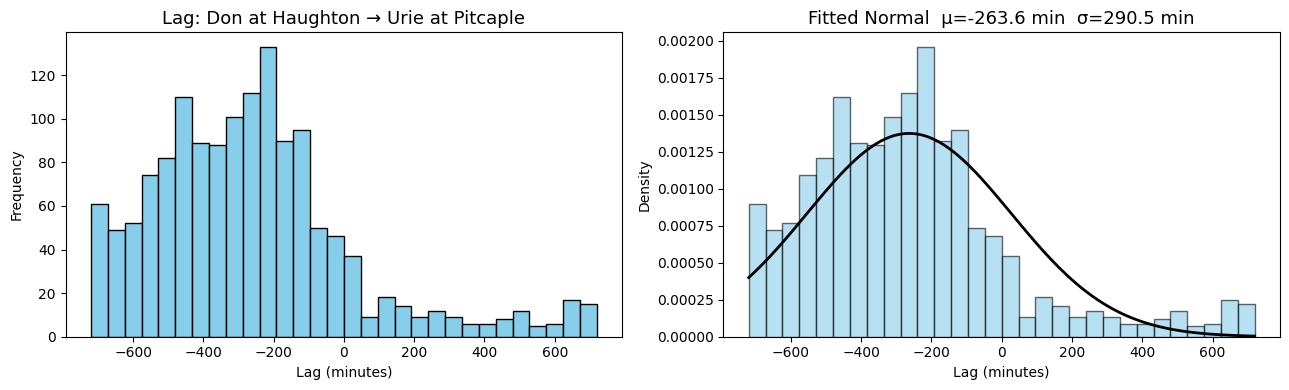

In [8]:
# Lag analysis — generalised for any number of tributaries
lag_stats = {}  # {trib_name: (mu_seconds, std_seconds)}

# Load reference tributary flow
ref = TRIBUTARIES[REF_IDX]
ref_df = pd.read_csv(ref['flow_file'], sep=ref['flow_sep'])
ref_df[ref['flow_timestamp_col']] = pd.to_datetime(ref_df[ref['flow_timestamp_col']])
ref_peaks, _ = find_peaks(ref_df[ref['flow_value_col']], height=0, prominence=0.5)
ref_times = ref_df[ref['flow_timestamp_col']].iloc[ref_peaks].reset_index(drop=True)

for idx in NON_REF_IDXS:
    t = TRIBUTARIES[idx]
    df = pd.read_csv(t['flow_file'], sep=t['flow_sep'])
    df[t['flow_timestamp_col']] = pd.to_datetime(df[t['flow_timestamp_col']])
    peaks, _ = find_peaks(df[t['flow_value_col']], height=0, prominence=0.5)
    peak_times = df[t['flow_timestamp_col']].iloc[peaks].reset_index(drop=True)

    lags_min = []
    for h_time in ref_times:
        diffs = peak_times - h_time
        closest = diffs[np.abs(diffs).argmin()].total_seconds() / 60
        if -720 <= closest <= 720:
            lags_min.append(closest)

    mu_min, std_min = scipy_norm.fit(lags_min)
    lag_stats[t['name']] = (mu_min * 60, std_min * 60)  # store in seconds

    print(f"[{t['label']}] Lag  mean: {mu_min:.1f} min  std: {std_min:.1f} min")

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].hist(lags_min, bins=30, color='skyblue', edgecolor='black')
    axes[0].set_title(f"Lag: {ref['label']} → {t['label']}", fontsize=13)
    axes[0].set_xlabel('Lag (minutes)')
    axes[0].set_ylabel('Frequency')

    axes[1].hist(lags_min, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black')
    x_fit = np.linspace(min(lags_min), max(lags_min), 200)
    axes[1].plot(x_fit, scipy_norm.pdf(x_fit, mu_min, std_min), 'k', linewidth=2)
    axes[1].set_title(f"Fitted Normal  μ={mu_min:.1f} min  σ={std_min:.1f} min", fontsize=13)
    axes[1].set_xlabel('Lag (minutes)')
    axes[1].set_ylabel('Density')

    plt.tight_layout()
    fig.savefig(os.path.join(FIGURES_DIR, f"lag_distribution_{t['name']}.png"), dpi=150)
    plt.show()

---
# Stage 2: Surrogate Model Construction
## Step 2: Generate Training Input Set (Sobol Sampling)

We construct a joint probability distribution overl all uncertain inputs:
- One **Uniform** distribution per tributary, with bounds taken from the GEV confidence interval at the target return period.
- One **Normal** distribution per non-reference tributary lag, parameterised by the mean and standard deviation fitted in Step 1b.

Sobol quasi-random sequences are used to generate the training input set. 

Joint distribution:
  Don at Haughton: Uniform(207.74, 422.82) m³/s
  Urie at Pitcaple: Uniform(47.35, 112.47) m³/s
  Lag (Urie at Pitcaple): Normal(μ=-15816s, σ=17430s)

Saved 3 sample arrays to: ./Inverurie_outputs/training_data/samples


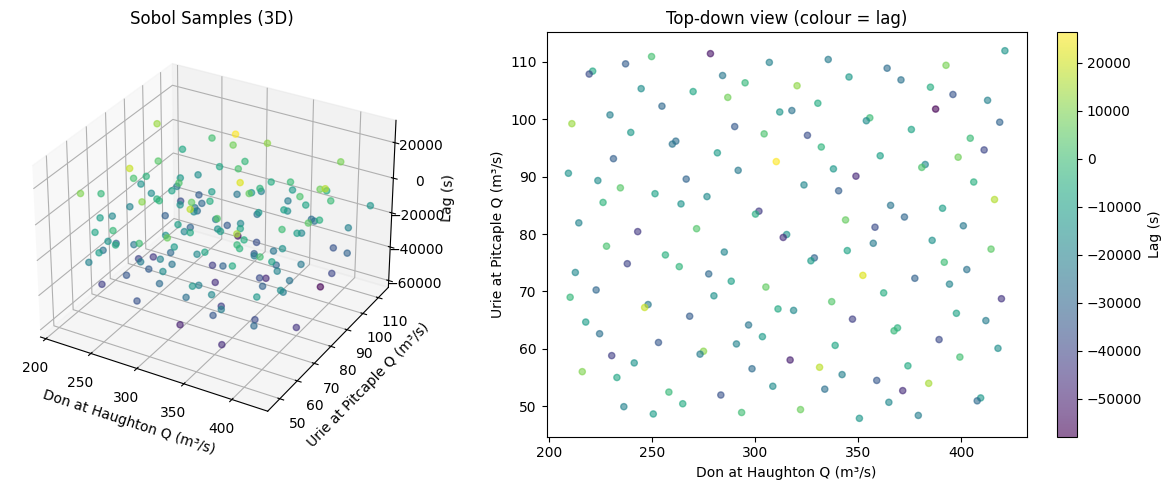

In [9]:
# Build joint distribution and generate Sobol samples
distributions = []
dist_labels   = []

print("Joint distribution:")
for t in TRIBUTARIES:
    b = gev_bounds[t['name']]
    distributions.append(cp.Uniform(b['lower'], b['upper']))
    dist_labels.append(t['name'])
    print(f"  {t['label']}: Uniform({b['lower']:.2f}, {b['upper']:.2f}) m³/s")

for idx in NON_REF_IDXS:
    t = TRIBUTARIES[idx]
    mu_s, std_s = lag_stats[t['name']]
    distributions.append(cp.Normal(mu_s, std_s))
    dist_labels.append(f"lag_{t['name']}")
    print(f"  Lag ({t['label']}): Normal(μ={mu_s:.0f}s, σ={std_s:.0f}s)")

joint         = cp.J(*distributions)
sobol_samples = joint.sample(N_SAMPLES, rule=SAMPLE_RULE)

# Store in a dict keyed by label
nodes = {dist_labels[i]: sobol_samples[i] for i in range(len(dist_labels))}

# Save each dimension to CSV
for label, arr in nodes.items():
    out_path = os.path.join(SAMPLES_DIR, f"nodes_{label}_{RETURN_PERIOD}yr_{N_SAMPLES}.csv")
    pd.DataFrame(arr).to_csv(out_path, index=False, header=False)

print(f"\nSaved {len(nodes)} sample arrays to: {SAMPLES_DIR}")

# 3D scatter (first 2 flows + first lag)
if len(distributions) >= 3:
    x, y, z = sobol_samples[0], sobol_samples[1], sobol_samples[2]
    fig = plt.figure(figsize=(13, 5))
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.scatter(x, y, z, c=z, cmap='viridis', alpha=0.6, s=20)
    ax1.set_xlabel(f"{TRIBUTARIES[0]['label']} Q (m³/s)")
    ax1.set_ylabel(f"{TRIBUTARIES[1]['label']} Q (m³/s)")
    ax1.set_zlabel('Lag (s)')
    ax1.set_title('Sobol Samples (3D)')
    ax2 = fig.add_subplot(122)
    sc = ax2.scatter(x, y, c=z, cmap='viridis', alpha=0.6, s=20)
    ax2.set_xlabel(f"{TRIBUTARIES[0]['label']} Q (m³/s)")
    ax2.set_ylabel(f"{TRIBUTARIES[1]['label']} Q (m³/s)")
    ax2.set_title('Top-down view (colour = lag)')
    plt.colorbar(sc, ax=ax2, label='Lag (s)')
    plt.tight_layout()
    fig.savefig(os.path.join(FIGURES_DIR, f"sobol_samples_{RETURN_PERIOD}yr.png"), dpi=150)
    plt.show()

## Step 3: Construct Synthetic Hydrographs

### Step 3a: Scale normalised hydrograph
We derived a single representative hydrograph shape from a historical flood event (here: the January 2016 event) and normalised it so that its peak equals 1. Each sampled peak inflow value is then used as a scaling factor, producing a hydrograph with the correct peak magnitude while preserving the observed shape of the flood wave. The scaling is applied to each upstream boundary section independently to each stream in the LISFLOOD-FP `.bdy` input file.



In [10]:
# Load flow sample arrays — from memory if available, else from CSV
flow_nodes = {}
for t in TRIBUTARIES:
    try:
        flow_nodes[t['name']] = nodes[t['name']]
        print(f"[{t['label']}] Using in-memory samples")
    except (NameError, KeyError):
        csv_path = os.path.join(SAMPLES_DIR, f"nodes_{t['name']}_{RETURN_PERIOD}yr_{N_SAMPLES}.csv")
        flow_nodes[t['name']] = pd.read_csv(csv_path, header=None)[0].values
        print(f"[{t['label']}] Loaded from CSV: {csv_path}")

# Load lag sample arrays
lag_nodes = {}
for idx in NON_REF_IDXS:
    t = TRIBUTARIES[idx]
    lag_key = f"lag_{t['name']}"
    try:
        lag_nodes[t['name']] = nodes[lag_key]
        print(f"[lag {t['label']}] Using in-memory samples")
    except (NameError, KeyError):
        csv_path = os.path.join(SAMPLES_DIR, f"nodes_{lag_key}_{RETURN_PERIOD}yr_{N_SAMPLES}.csv")
        lag_nodes[t['name']] = pd.read_csv(csv_path, header=None)[0].values
        print(f"[lag {t['label']}] Loaded from CSV: {csv_path}")

[Don at Haughton] Using in-memory samples
[Urie at Pitcaple] Using in-memory samples
[lag Urie at Pitcaple] Using in-memory samples


In [11]:
# ── Step 3a: Scale hydrographs ──────────────────────────────────────────────
def modify_bdy_file(input_file, output_file, factors):
    """Scale .bdy file sections by their respective factors.
    factors: dict of {bdy_section_name: scale_factor}"""
    with open(input_file, 'r') as f:
        lines = f.readlines()
    current_section = None
    with open(output_file, 'w') as f:
        for line in lines:
            matched = next((t['bdy_section'] for t in TRIBUTARIES
                            if line.strip().startswith(t['bdy_section'])), None)
            if matched:
                current_section = matched
                f.write(line)
                continue
            if current_section in factors:
                parts = line.split()
                if len(parts) >= 2 and parts[1] != 'seconds':
                    try:
                        value = float(parts[0]) * factors[current_section] / 5
                        f.write(f"{value}\t{chr(9).join(parts[1:])}\n")
                        continue
                    except ValueError:
                        pass
            f.write(line)

os.makedirs(BDY_SCALED_DIR, exist_ok=True)
n_files = len(next(iter(flow_nodes.values())))

for i in range(n_files):
    factors = {t['bdy_section']: flow_nodes[t['name']][i] for t in TRIBUTARIES}
    out_path = os.path.join(BDY_SCALED_DIR, f"sobol_{i+1}.bdy")
    modify_bdy_file(BDY_TEMPLATE, out_path, factors)

print(f"Created {n_files} scaled .bdy files in: {BDY_SCALED_DIR}")

Created 150 scaled .bdy files in: ./Inverurie_outputs/training_data/bdy_scaled


### Step 3b: Apply lag
The sampled lag is applied to shift the non-reference tributary hydrograph in time, using cubic spline interpolation. The sampled lag is applied to the non-reference tributary by shifting its hydrograph in time. Cubic spline interpolation is used to resample the shifted hydrograph onto the original time steps.

In [12]:
# ── Step 3b: Apply lag shift ────────────────────────────────────────────────

def find_section_start(lines, section_name):
    for i, line in enumerate(lines):
        if section_name in line.strip():
            return i
    raise ValueError(f"Section '{section_name}' not found in file.")

def apply_lag_shift(input_file, output_file, shift_seconds, section_name):
    """Shift the specified .bdy section in time by shift_seconds using cubic spline."""
    with open(input_file, 'r') as f:
        lines = f.readlines()

    start_idx = find_section_start(lines, section_name) + 2
    time, flow = [], []
    for line in lines[start_idx:]:
        if not line.strip() or 'seconds' in line:
            continue
        try:
            fv, tv = map(float, line.split())
            flow.append(fv)
            time.append(tv)
        except ValueError:
            continue

    time = np.array(time)
    flow = np.array(flow)
    spline       = splrep(time, flow)
    shifted_flow = splev(time - shift_seconds, spline)
    shifted_flow[0] = 0
    shifted_flow[shifted_flow < 0] = 0

    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    with open(output_file, 'w') as f:
        for line in lines[:start_idx]:
            f.write(line)
        for t_val, fl in zip(time, shifted_flow):
            f.write(f"{fl:.9f}\t{t_val}\n")
        f.writelines(lines[start_idx + len(shifted_flow):])

# Apply lag shifts for each non-reference tributary
bdy_files = sorted([f for f in os.listdir(BDY_SCALED_DIR) if f.endswith('.bdy')])
print(f"Found {len(bdy_files)} scaled .bdy files")

for idx in NON_REF_IDXS:
    t = TRIBUTARIES[idx]
    shift_values = lag_nodes[t['name']]
    section      = t['bdy_section']
    print(f"\nApplying lag shifts for: {t['label']} (section: {section})")

    for i, bdy_file in enumerate(bdy_files):
        if i >= len(shift_values):
            print(f"  No lag value for {bdy_file}, skipping")
            continue
        in_path  = os.path.join(BDY_SCALED_DIR, bdy_file)
        out_path = os.path.join(BDY_SHIFTED_DIR, bdy_file)
        apply_lag_shift(in_path, out_path, shift_values[i], section)

print(f"\nDone. Final hydrograph files saved to: {BDY_SHIFTED_DIR}")

Found 151 scaled .bdy files

Applying lag shifts for: Urie at Pitcaple (section: upstream2)
  No lag value for sobol_99.bdy, skipping

Done. Final hydrograph files saved to: ./Inverurie_outputs/training_data/bdy_shifted


In [13]:
# code to generate a hydrograph for the deterministic case
# ── Single hydrograph: fixed peak inflows, zero lag ──────────────────────────
factors = {
    "upstream1": 281.74,   # here: Don. The numbers here come from JBA: http://www.inveruriefloodstudy.com/media/reports/Hydrology.pdf
    "upstream2": 88.07,    # here: Urie
}

out_path = os.path.join(BDY_SCALED_DIR, "single_Don281_Urie88_lag0.bdy")
modify_bdy_file(BDY_TEMPLATE, out_path, factors)
print(f"Created: {out_path}")

Created: ./Inverurie_outputs/training_data/bdy_scaled\single_Don281_Urie88_lag0.bdy


---
## Step 4: Run the Hydraulic Model

Run LISFLOOD-FP for each `.bdy` file in `bdy_shifted/`. LISFLOOD-FP is a 2D hydrodynamic model that solves the shallow water equations on a regular grid. It is widely used for flood inundation modelling due to its computational efficiency and ability to simulate sub-critical and super-critical flow regimes.

Each simulation produces a `.max` file containing the maximum inundation depth at every grid cell over the full simulation period. These maximum depth maps are the training outputs for the surrogate model.

Place all `.max` output files into the folder specified by `FLOOD_MAPS_DIR` before proceeding to Step 5.

Expected output filenames: `test_Res_1.max`, `test_Res_2.max`, ... `test_Res_N.max`

---
## Step 5: Train the Surrogate Model

### Dimensionality Reduction via POD
Maximum inundation depth maps have one value per grid cell (here: 612 × 952 = ~582,000 values), making it impractical to fit a separate surrogate to each cell directly. Instead, **Proper Orthogonal Decomposition (POD)** of the snapshot matrix is used to identify the dominant spatial patterns (modes) in the training data. A small number of modes (typically 10) captures the vast majority of the variance in the ensemble, compressing the output from ~582,000 dimensions to just 10 scalar coefficients per simulation.

### PCK Surrogate
A **Polynomial Chaos Kriging (PCK)** model is fitted independently to each of the 10 POD coefficients. PCK combines:
- A **PCE (Polynomial Chaos Expansion)** trend of degree 2, which uses orthogonal polynomials matched to the input distributions to capture the dominant response surface.
- A **GPR (Gaussian Process Regression)** residual using a Gaussian covariance kernel, which captures non-linear departures from the polynomial trend and provides a variance estimate at any new input point.

Inputs are normalised to zero mean and unit variance before fitting to ensure numerical stability of the Kriging system.

In [14]:
# Helper: read a LISFLOOD .max file
def process_flood_file(file_path, nrows=NROWS, ncols=NCOLS):
    try:
        with open(file_path, 'r') as f:
            lines = f.readlines()
        if len(lines) <= 6:
            print(f"File {file_path} has too few lines. Skipping.")
            return None
        flood_data = []
        for line in lines[6:]:
            try:
                flood_data.extend([float(v) for v in line.split()])
            except ValueError:
                print(f"Malformed line in {file_path}. Skipping file.")
                return None
        if len(flood_data) != nrows * ncols:
            print(f"Unexpected data size in {file_path}. Skipping.")
            return None
        return np.array(flood_data).reshape((nrows, ncols))
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        return None

Loaded flow nodes: Don at Haughton  (150 samples)
Loaded flow nodes: Urie at Pitcaple  (150 samples)
Loaded lag nodes:  Urie at Pitcaple  (150 samples)

Inputs matrix shape: (3, 150)  (3 dims × 150 samples)


Loading flood maps: 100%|████████████████████████████████████████████████████████████████| 150/150 [00:48<00:00,  3.07it/s]


Snapshot matrix shape: (900000, 150)  (pixels × snapshots)

Variance explained by 6 POD modes: 99.99%


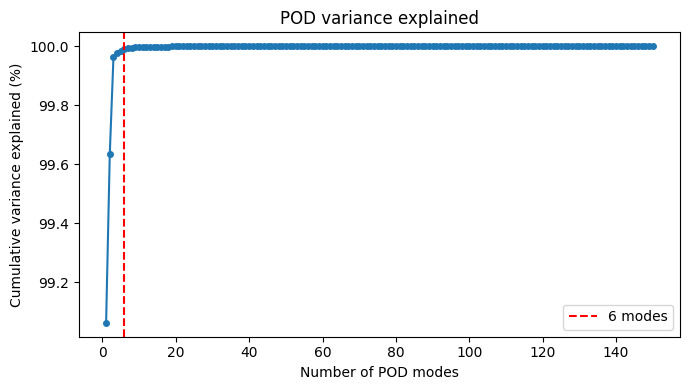

In [15]:
# ── Step 5: Load Training Data (we assume from csv as flood model takes a while to run) ──────────────────────────────────────────────
# Set these paths manually after LISFLOOD has finished running
FLOOD_MAPS_DIR  = "C:/Users/nfische2/Documents/case_study/Inverurie_outputs/flood_maps"  # folder with .max files
NODES_LIST_DIR  = "Z:/inverurie_data/Inverurie_emulator_Inputs"   # folder with nodes CSVs — leave as SAMPLES_DIR or override
# NODES_LIST_DIR  = SAMPLES_DIR   # folder with nodes CSVs — leave as SAMPLES_DIR or override

# Load input sample arrays from CSV
all_arrays = []
for t in TRIBUTARIES:
    csv_path = os.path.join(NODES_LIST_DIR, f"nodes_{t['name']}_{RETURN_PERIOD}yr_{N_SAMPLES}.csv")
    arr = pd.read_csv(csv_path, header=None)[0].values
    all_arrays.append(arr)
    print(f"Loaded flow nodes: {t['label']}  ({len(arr)} samples)")

for idx in NON_REF_IDXS:
    t = TRIBUTARIES[idx]
    lag_key  = f"lag_{t['name']}"
    csv_path = os.path.join(NODES_LIST_DIR, f"nodes_{lag_key}_{RETURN_PERIOD}yr_{N_SAMPLES}.csv")
    arr = pd.read_csv(csv_path, header=None)[0].values
    all_arrays.append(arr)
    print(f"Loaded lag nodes:  {t['label']}  ({len(arr)} samples)")

inputs_matrix = np.vstack(all_arrays)[:, :N_SAMPLES]
print(f"\nInputs matrix shape: {inputs_matrix.shape}  ({inputs_matrix.shape[0]} dims × {inputs_matrix.shape[1]} samples)")

# Load flood map snapshots from LISFLOOD output folder
snapshots = []
missing   = []

for i in tqdm(range(1, N_SAMPLES + 1), desc="Loading flood maps"):
    file_path = os.path.join(FLOOD_MAPS_DIR, f"test_Res_{i}.max")
    flood_map = process_flood_file(file_path)
    if flood_map is not None:
        snapshots.append(flood_map.flatten())
    else:
        missing.append(i)

if missing:
    print(f"\nWarning: {len(missing)} files missing or unreadable: {missing}")

snapshot_matrix = np.array(snapshots).T
print(f"Snapshot matrix shape: {snapshot_matrix.shape}  (pixels × snapshots)")

# POD via SVD
N_POD_MODES = 6
U, S, Vt = svd(snapshot_matrix, full_matrices=False)
pod_coefficients = np.dot(U.T, snapshot_matrix)
pod_coeff_trunc  = pod_coefficients[:N_POD_MODES, :].T

explained = np.cumsum(S**2) / np.sum(S**2)
print(f"\nVariance explained by {N_POD_MODES} POD modes: {explained[N_POD_MODES-1]*100:.2f}%")

# Plot explained variance
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(S)+1), np.cumsum(S**2)/np.sum(S**2)*100, marker='o', markersize=4)
plt.axvline(N_POD_MODES, color='red', linestyle='--', label=f'{N_POD_MODES} modes')
plt.xlabel('Number of POD modes')
plt.ylabel('Cumulative variance explained (%)')
plt.title('POD variance explained')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "pod_variance_explained.png"), dpi=150)
plt.show()

In [16]:
# Fit PCK surrogate
n_dims = inputs_matrix.shape[0]

# Normalise inputs
scaler_X    = StandardScaler()
X_train_norm = scaler_X.fit_transform(inputs_matrix.T)  # (snapshots, n_dims)

# Normalise POD outputs
scalers_Y    = []
Y_train_norm = np.zeros_like(pod_coeff_trunc)
for j in range(pod_coeff_trunc.shape[1]):
    sc = StandardScaler()
    Y_train_norm[:, j] = sc.fit_transform(pod_coeff_trunc[:, j].reshape(-1, 1)).ravel()
    scalers_Y.append(sc)

# PCE polynomial basis
dists_norm  = [cp.Normal(0, 1) for _ in range(n_dims)]
joint_norm  = cp.J(*dists_norm)
expansion   = cp.generate_expansion(2, joint_norm)

# Fit one Kriging model per POD mode
model_gst = gstools.Gaussian(dim=n_dims, var=1)
pck_models = []
for i in range(Y_train_norm.shape[1]):
    pck = gstools.krige.Universal(
        model_gst,
        cond_pos=X_train_norm.T,
        cond_val=Y_train_norm[:, i],
        drift_functions=list(expansion)
    )
    pck_models.append(pck)
    print(f"  Fitted PCK model for POD mode {i+1}/{N_POD_MODES}")

print("\nSurrogate training complete.")

joblib.dump({
    'pck_models':    pck_models,
    'scaler_X':      scaler_X,
    'scalers_Y':     scalers_Y,
    'U':             U,
    'S':             S,
    'N_POD_MODES':   N_POD_MODES,
    'NROWS':         NROWS,
    'NCOLS':         NCOLS,
    'X_train_norm':  X_train_norm,
    'Y_train_norm':  Y_train_norm,
    'inputs_matrix': inputs_matrix,
}, os.path.join(OUTPUT_BASE, 'trained_surrogate.joblib'))

print(f"Surrogate saved to: {os.path.join(OUTPUT_BASE, 'trained_surrogate.joblib')}")

  Fitted PCK model for POD mode 1/6
  Fitted PCK model for POD mode 2/6
  Fitted PCK model for POD mode 3/6
  Fitted PCK model for POD mode 4/6
  Fitted PCK model for POD mode 5/6
  Fitted PCK model for POD mode 6/6

Surrogate training complete.
Surrogate saved to: ./Inverurie_outputs\trained_surrogate.joblib


---
## Step 6: Validate the Surrogate

Apply a leave one out k-fold validation approach and compare surrogate predictions against the full model outputs.

  Fold 1/10 complete  (train=135, test=15)
  Fold 2/10 complete  (train=135, test=15)
  Fold 3/10 complete  (train=135, test=15)
  Fold 4/10 complete  (train=135, test=15)
  Fold 5/10 complete  (train=135, test=15)
  Fold 6/10 complete  (train=135, test=15)
  Fold 7/10 complete  (train=135, test=15)
  Fold 8/10 complete  (train=135, test=15)
  Fold 9/10 complete  (train=135, test=15)
  Fold 10/10 complete  (train=135, test=15)


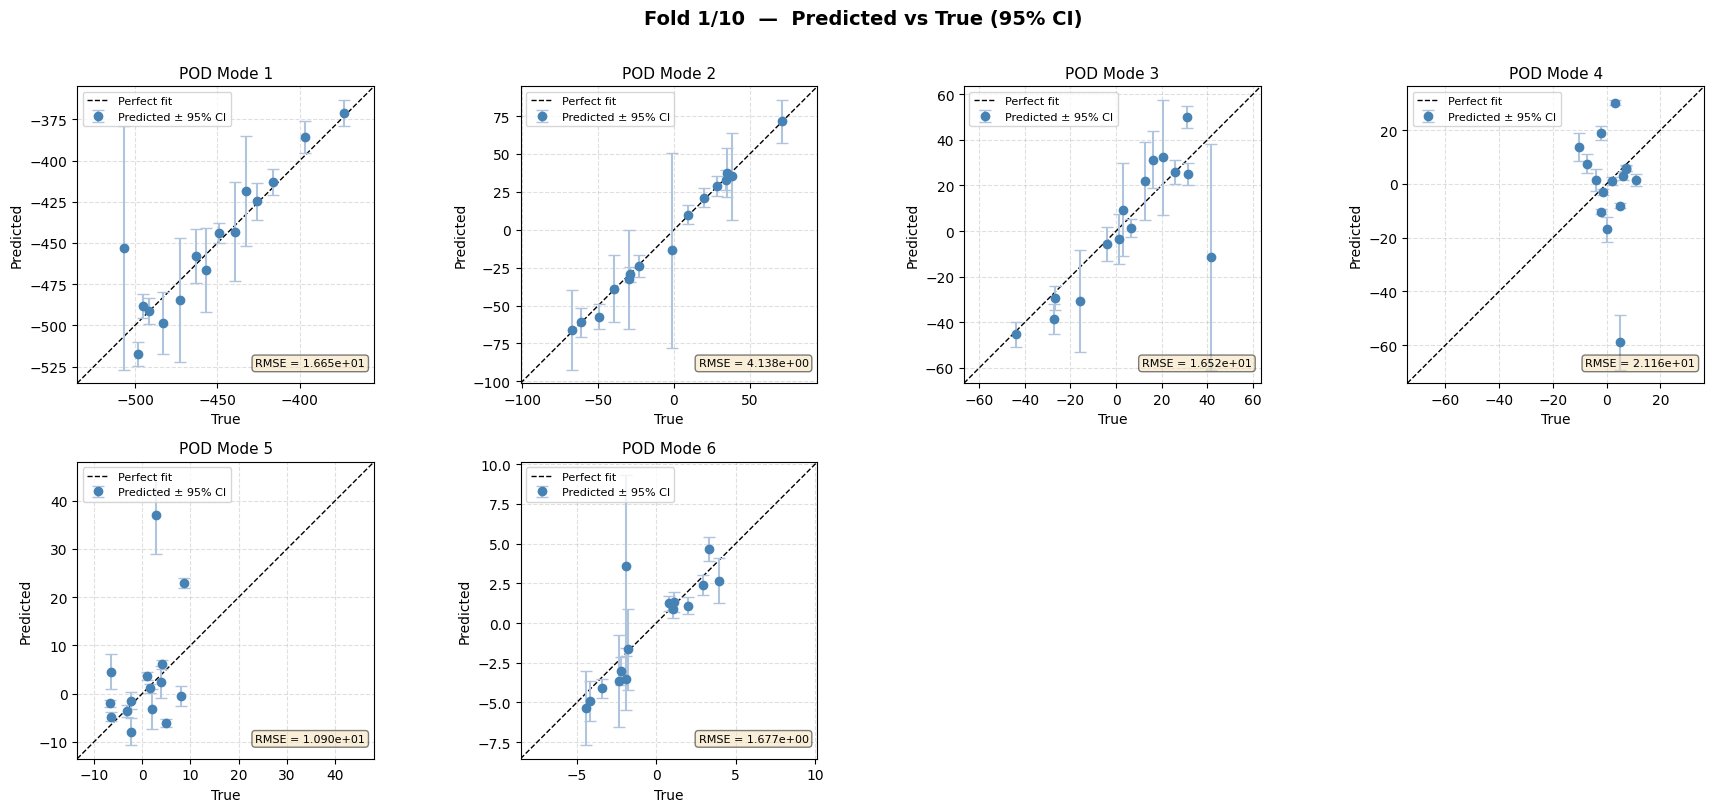

In [17]:
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── 10-Fold CV (stores fold info for plotting) ────────────────────────────────
K         = 10
n_samples = X_train_norm.shape[0]
n_modes   = Y_train_norm.shape[1]

kf = KFold(n_splits=K, shuffle=True, random_state=42)

cv_preds_norm  = np.zeros_like(Y_train_norm)
cv_preds_phys  = np.zeros_like(Y_train_norm)
cv_vars_phys   = np.zeros_like(Y_train_norm)   # variance in physical space
cv_vars_norm   = np.zeros_like(Y_train_norm)
cv_fold_ids    = np.zeros(n_samples, dtype=int) # which fold each sample is test in

Y_true_phys = np.zeros_like(Y_train_norm)
for j in range(n_modes):
    Y_true_phys[:, j] = scalers_Y[j].inverse_transform(
        Y_train_norm[:, j].reshape(-1, 1)).ravel()

for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X_train_norm)):
    cv_fold_ids[test_idx] = fold_idx

    # Re-normalise inputs
    scaler_X_fold = StandardScaler()
    X_phys_train  = scaler_X.inverse_transform(X_train_norm[train_idx])
    X_phys_test   = scaler_X.inverse_transform(X_train_norm[test_idx])
    X_fold_train  = scaler_X_fold.fit_transform(X_phys_train)
    X_fold_test   = scaler_X_fold.transform(X_phys_test)

    # Re-normalise POD coefficients
    Y_fold_train   = np.zeros((len(train_idx), n_modes))
    scalers_Y_fold = []
    for j in range(n_modes):
        sc     = StandardScaler()
        Y_phys = scalers_Y[j].inverse_transform(
                     Y_train_norm[train_idx, j].reshape(-1, 1))
        Y_fold_train[:, j] = sc.fit_transform(Y_phys).ravel()
        scalers_Y_fold.append(sc)

    # Fit & predict
    for j in range(n_modes):
        model_fold = gstools.krige.Universal(
            gstools.Gaussian(dim=n_dims, var=1),
            cond_pos=X_fold_train.T,
            cond_val=Y_fold_train[:, j],
            drift_functions=list(expansion),
        )
        pred_norm, var_norm = model_fold(X_fold_test.T)

        cv_preds_norm[test_idx, j] = pred_norm
        cv_vars_norm [test_idx, j] = var_norm

        # Back-transform to physical space
        # For StandardScaler: y_phys = scale_ * y_norm + mean_
        # so std_phys = scale_ * sqrt(var_norm)
        scale = scalers_Y_fold[j].scale_[0]
        cv_preds_phys[test_idx, j] = scalers_Y_fold[j].inverse_transform(
            pred_norm.reshape(-1, 1)).ravel()
        cv_vars_phys[test_idx, j]  = var_norm * scale**2   # variance in phys space

    print(f"  Fold {fold_idx+1}/{K} complete  "
          f"(train={len(train_idx)}, test={len(test_idx)})")

# ── Predicted vs True plots — one figure per fold ────────────────────────────
ncols  = min(n_modes, 4)
nrows  = int(np.ceil(n_modes / ncols))
z95    = 1.96   # 95% CI multiplier

# Plot only fold 1 (change 0 to whichever fold you want, 0-indexed):
fold_idx = 0

test_mask = cv_fold_ids == fold_idx

y_true = Y_true_phys  [test_mask]
y_pred = cv_preds_phys[test_mask]
y_std  = np.sqrt(cv_vars_phys[test_mask])

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(4.5 * ncols, 4 * nrows),
                         squeeze=False)
fig.suptitle(f"Fold {fold_idx + 1}/{K}  —  Predicted vs True (95% CI)",
             fontsize=14, fontweight='bold', y=1.01)

for j, ax in enumerate(axes.flat):
    if j >= n_modes:
        ax.set_visible(False)
        continue

    t = y_true[:, j]
    p = y_pred[:, j]
    s = y_std [:, j] * z95

    lo = min(t.min(), (p - s).min())
    hi = max(t.max(), (p + s).max())
    pad = (hi - lo) * 0.05
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad],
            'k--', lw=1, label='Perfect fit')
    ax.errorbar(t, p, yerr=s,
                fmt='o', color='steelblue', ecolor='lightsteelblue',
                elinewidth=1.5, capsize=4, markersize=6,
                label='Predicted ± 95% CI')
    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('True', fontsize=10)
    ax.set_ylabel('Predicted', fontsize=10)
    ax.set_title(f'POD Mode {j + 1}', fontsize=11)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.4)

    rmse = np.sqrt(np.mean((t - p)**2))
    ax.text(0.97, 0.05, f'RMSE = {rmse:.3e}',
            transform=ax.transAxes, fontsize=8,
            ha='right', va='bottom',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.5))

fig.tight_layout()
plt.savefig(os.path.join(OUTPUT_BASE, f'cv_fold_{fold_idx+1:02d}_pred_vs_true.png'),
            dpi=150, bbox_inches='tight')
plt.show()

---
# Stage 3: Probabilistic Flood Mapping
## Steps 7–9: Sample → Predict → Aggregate

We generate a large Monte Carlo ensemble of inflow combinations at the target return period, pass them through the trained surrogate, and aggregate to produce probabilistic flood maps.

In [18]:
# Load trained surrogate from disk if not already in memory
try:
    _ = pck_models
    print("Using in-memory surrogate.")
except NameError:
    print("Loading surrogate from disk...")
    surrogate = joblib.load(os.path.join(OUTPUT_BASE, 'trained_surrogate.joblib'))
    pck_models    = surrogate['pck_models']
    scaler_X      = surrogate['scaler_X']
    scalers_Y     = surrogate['scalers_Y']
    U             = surrogate['U']
    N_POD_MODES   = surrogate['N_POD_MODES']
    NROWS         = surrogate['NROWS']
    NCOLS         = surrogate['NCOLS']
    X_train_norm  = surrogate['X_train_norm']
    Y_train_norm = surrogate['Y_train_norm']
    n_dims = surrogate['inputs_matrix'].shape[0]
    inputs_matrix = surrogate['inputs_matrix']

    print("surrogate loaded.")

Using in-memory surrogate.


In [19]:
# Step 7: Generate large Monte Carlo ensemble
N_MC = 1000  # adjust as needed

mc_samples = joint.sample(N_MC, rule='random', seed=42)
mc_inputs  = np.array(mc_samples)  # shape: (n_dims, N_MC)

# Save for reproducibility
pd.DataFrame(mc_inputs.T,
             columns=dist_labels).to_csv()

print(f"Generated {N_MC} Monte Carlo samples across {n_dims} dimensions.")

Generated 1000 Monte Carlo samples across 3 dimensions.


## Joint Prediction with POD-PCK Surrogate

We follow the notation of Rasmussen & Williams (2006), denoting training inputs $X = \{\mathbf{x}_i\}_{i=1}^{n}$, training targets $\mathbf{y}$, and prediction inputs $X_* = \{\mathbf{x}_*^{(i)}\}_{i=1}^{N_{MC}}$, which are drawn from the joint distribution defined by `joint` after the lag calculation.

---

### The Kriging Model

We fit an independent kriging model to each POD coefficient field $\alpha_k(\mathbf{x})$. The model assumes that $\alpha_k$ is a realisation of a second-order stationary random function,

$$\alpha_k(\mathbf{x}) = m_k(\mathbf{x}) + \varepsilon(\mathbf{x})$$

where $m_k(\mathbf{x}) = \mathbf{h}(\mathbf{x})^\top \boldsymbol{\beta}_k$ is a polynomial chaos expansion (PCE) trend function with basis functions $\mathbf{h}(\mathbf{x})$ and GLS-estimated coefficients $\hat{\boldsymbol{\beta}}_k$, and $\varepsilon(\mathbf{x})$ is a zero-mean stationary residual with covariance function

$$C(\mathbf{x}, \mathbf{x}') = \sigma^2 \exp\left(-\frac{\|\mathbf{x} - \mathbf{x}'\|^2}{2\ell^2}\right)$$

with marginal variance $\sigma^2$ (`C0` in code) and length-scale $\ell$, both estimated by maximum likelihood. In GStools, the covariance function is obtained from the variogram $\gamma(\cdot)$ via

$$C(\mathbf{x}, \mathbf{x}') = \sigma^2 - \gamma(\|\mathbf{x} - \mathbf{x}'\|)$$

which corresponds to `C0 - pck_models[0].model.variogram(dists)` in the code.

---

### Covariance Matrices

Three covariance matrices are required for joint prediction. Using $C(\cdot, \cdot)$:

$$\mathbf{K}_{tt} = C(X, X) \in \mathbb{R}^{n \times n} \qquad \text{(training covariance)}$$

$$\mathbf{K}_{*t} = C(X_*, X) \in \mathbb{R}^{N_{MC} \times n} \qquad \text{(cross-covariance)}$$

$$\mathbf{K}_{**} = C(X_*, X_*) \in \mathbb{R}^{N_{MC} \times N_{MC}} \qquad \text{(prediction covariance)}$$

A small diagonal jitter term $\epsilon \mathbf{I}$ is added to $\mathbf{K}_{tt}$ for numerical stability:

$$\mathbf{K}_{tt} \leftarrow \mathbf{K}_{tt} + \epsilon \mathbf{I}, \qquad \epsilon = 10^{-8}$$

---

### Kriging Prediction and Uncertainty

The universal kriging predictor at $X_*$ is

$$\hat{\boldsymbol{\alpha}}_k(X_*) = \mathbf{H}(X_*)^\top \hat{\boldsymbol{\beta}}_k + \mathbf{K}_{*t}\mathbf{K}_{tt}^{-1}(\mathbf{y}_k - \mathbf{H}(X)^\top \hat{\boldsymbol{\beta}}_k)$$

where $\mathbf{H}(X)$ contains the PCE basis functions evaluated at training points. This is computed by GStools and accessed through `pck.field` after calling `pck(X_*.T, return_var=True)`.

The kriging error covariance matrix between all $N_{MC}$ prediction points is

$$\boldsymbol{\Sigma}_* = \mathbf{K}_{**} - \mathbf{K}_{*t}\mathbf{K}_{tt}^{-1}\mathbf{K}_{t*}$$

This quantifies the interpolation uncertainty of the kriging predictor — it is large where prediction points are far from training data and zero at training points. $\mathbf{K}_{tt}^{-1}\mathbf{K}_{t*}$ is computed via `np.linalg.solve` rather than explicit matrix inversion for numerical stability. Critically, $\boldsymbol{\Sigma}_*$ depends only on the input locations $X, X_*$ and the covariance function hyperparameters — not on the training targets $\mathbf{y}$ — and is therefore identical for all POD modes. It is computed once and reused.

---

### Joint Simulation via Cholesky Decomposition

To propagate kriging uncertainty through the POD reconstruction, we draw $S$ jointly consistent realisations of the kriging error using the Cholesky decomposition of $\boldsymbol{\Sigma}_*$ (R&W A.2),

$$\boldsymbol{\Sigma}_* = \mathbf{L}\mathbf{L}^\top$$

where $\mathbf{L} \in \mathbb{R}^{N_{MC} \times N_{MC}}$ is lower triangular. Realisations are generated as

$$\tilde{\boldsymbol{\alpha}}_k^{(s)} = \hat{\boldsymbol{\alpha}}_k(X_*) + \mathbf{L}\mathbf{u}^{(s)}, \qquad \mathbf{u}^{(s)} \sim \mathcal{N}(\mathbf{0}, \mathbf{I}_{N_{MC}}), \quad s = 1, \ldots, S$$

yielding the realisation matrix $\tilde{\mathbf{A}}_k \in \mathbb{R}^{N_{MC} \times S}$ (`samples_norm` in the code). Each column $\tilde{\boldsymbol{\alpha}}_k^{(s)}$ is a single jointly consistent realisation of the $k$-th POD coefficient field over all prediction points simultaneously, centred on the kriging predictor and consistent with the kriging error covariance.

Realisations are then mapped back to physical space via the inverse standardisation,

$$\hat{\boldsymbol{\alpha}}_k^{(s)} = \sigma_k^Y \tilde{\boldsymbol{\alpha}}_k^{(s)} + \mu_k^Y$$

where $\mu_k^Y$ and $\sigma_k^Y$ are the mean and standard deviation of the $k$-th POD coefficient over the training data (`scalers_Y[k]` in the code).

---

### POD Reconstruction

Given the $K$ POD modes $\{\boldsymbol{\phi}_k\}_{k=1}^K$ stored as columns of $\mathbf{U}_K \in \mathbb{R}^{N_{px} \times K}$, the flood field for MC sample $i$ and realisation $s$ is reconstructed as

$$\mathbf{q}^{(i,s)} = \sum_{k=1}^{K} \hat{\alpha}_k^{(i,s)} \boldsymbol{\phi}_k = \hat{\mathbf{a}}^{(i,s)} \mathbf{U}_K^\top \in \mathbb{R}^{N_{px}}$$

where $\hat{\mathbf{a}}^{(i,s)} \in \mathbb{R}^K$ is the row vector of POD coefficients for sample $(i,s)$. Physical non-negativity of water depth is enforced by

$$\mathbf{q}^{(i,s)} \leftarrow \max\left(\mathbf{q}^{(i,s)}, \mathbf{0}\right)$$

The full ensemble of realisations $\{\mathbf{q}^{(i,s)}\}_{i,s}$ contains $N_{MC} \times S$ flood maps and is used for uncertainty quantification in the subsequent analysis.

In [20]:
# Joint prediction
rng          = np.random.default_rng(42)
n_gp_samples = 5  # 50 causes memory issues
X_mc         = scaler_X.transform(mc_inputs.T)   # (N_MC, n_dims)

# Compute covariance matrices ONCE outside loop (don't depend on POD mode)
X_train   = X_train_norm   # (n_train, n_dims) 
n_train   = X_train.shape[0]
C0        = pck_models[0].model.var

# K(X_train, X_train)
diffs_tt  = X_train[:, None, :] - X_train[None, :, :]
dists_tt  = np.sqrt(np.sum(diffs_tt**2, axis=-1))
K_tt      = C0 - pck_models[0].model.variogram(dists_tt)
K_tt     += 1e-8 * np.eye(n_train)

# K(X*, X_train)  
diffs_st  = X_mc[:, None, :] - X_train[None, :, :]
dists_st  = np.sqrt(np.sum(diffs_st**2, axis=-1))
K_st      = C0 - pck_models[0].model.variogram(dists_st)   # (N_MC, n_train)

# K(X*, X*) — prior covariance
diffs     = X_mc[:, None, :] - X_mc[None, :, :]  
dists     = np.sqrt(np.sum(diffs**2, axis=-1))
C         = pck_models[0].model.correlation(dists)
K_ss      = C0 * C   # (N_MC, N_MC)

# Exact posterior covariance: Sigma* = K** - K*t K_tt^{-1} K_t*
K_tt_inv_Kst = np.linalg.solve(K_tt, K_st.T)  
Sigma_exact  = K_ss - K_st @ K_tt_inv_Kst
Sigma_exact += 1e-9 * np.eye(N_MC)
L_exact      = np.linalg.cholesky(Sigma_exact)   # computed once, reused per mode

all_coeffs_samples = np.zeros((N_MC, N_POD_MODES, n_gp_samples))

for model_idx, pck in enumerate(pck_models):
    pck(X_mc.T, return_var=True) # this creates the prediction
    mean_norm = pck.field   # (N_MC,) normalised
    
    z            = rng.standard_normal((N_MC, n_gp_samples)) # as in R&W A.2
    samples_norm = mean_norm[:, None] + L_exact @ z   # (N_MC, n_gp_samples), generate samples x ∼ N (m, K) with mean_norm and covariance from GP 
    
    sc           = scalers_Y[model_idx]
    samples_phys = sc.inverse_transform(
        samples_norm.reshape(-1,1)).reshape(N_MC, n_gp_samples)
    all_coeffs_samples[:, model_idx, :] = samples_phys
    print(f"Mode: {model_idx}")

    
# Reconstruction preparation
coeff_t       = all_coeffs_samples.transpose(0, 2, 1)   # (N_MC, n_gp_samples, n_modes)
U_trunc       = U[:, :N_POD_MODES].astype(np.float32)  

Mode: 0
Mode: 1
Mode: 2
Mode: 3
Mode: 4
Mode: 5


In [25]:
import numpy as np
from tqdm.notebook import tqdm
import time

N_space = NROWS * NCOLS
depth_threshold = 0.01

# all_coeffs_samples: shape (N_MC, N_POD_MODES, ?)
# Your code did:
#   coeff_batch = all_coeffs_samples[start:end, :, :].transpose(0, 2, 1)
# giving shape (batch_size, ?, N_POD_MODES)
#
# We will follow the same pattern and then flatten to (batch_samples, N_POD_MODES),
# so total_samples is the total number of rows in that flattened array over all batches.

N_MC = all_coeffs_samples.shape[0]
batch_size = 20
num_batches = N_MC // batch_size
batch_ranges = [(i * batch_size, (i + 1) * batch_size) for i in range(num_batches)]

# Figure out total_samples by looking at a single batch
example_batch = all_coeffs_samples[0:batch_size, :, :].transpose(0, 2, 1)
batch_samples = example_batch.reshape(-1, example_batch.shape[-1]).shape[0]
total_samples = batch_samples * num_batches
print(f"Total samples (across all MC runs and any extra dimension): {total_samples}")

# Output arrays (flattened)
prob_flat = np.zeros(N_space, dtype=np.float16)
p05_flat  = np.zeros(N_space, dtype=np.float16)
p10_flat  = np.zeros(N_space, dtype=np.float16)
p25_flat  = np.zeros(N_space, dtype=np.float16)
p50_flat  = np.zeros(N_space, dtype=np.float16)
p75_flat  = np.zeros(N_space, dtype=np.float16)
p90_flat  = np.zeros(N_space, dtype=np.float16)
p95_flat  = np.zeros(N_space, dtype=np.float16)

# Choose how many spatial points per chunk.
# Memory per chunk ~ total_samples * chunk_size * 4 bytes
chunk_size = 2000  # adjust based on your RAM

start_time = time.time()

for pix_start in tqdm(range(0, N_space, chunk_size),
                      desc='Spatial chunks',
                      unit='chunk'):
    pix_end = min(pix_start + chunk_size, N_space)
    n_chunk = pix_end - pix_start

    # Basis for this spatial chunk: shape (n_chunk, N_POD_MODES)
    U_chunk = U_trunc[pix_start:pix_end, :]

    # This will hold depths for *all* samples for this spatial chunk:
    # shape (total_samples, n_chunk)
    samples_chunk = np.empty((total_samples, n_chunk), dtype=np.float16)

    # Fill samples_chunk batch by batch
    s0 = 0
    for start, end in batch_ranges:
        # Same transform as your original code
        coeff_batch = all_coeffs_samples[start:end, :, :].transpose(0, 2, 1).astype(np.float32)
        coeff_flat  = coeff_batch.reshape(-1, coeff_batch.shape[-1])  # (batch_samples, N_POD_MODES)

        # Reconstruct for this chunk only: shape (batch_samples, n_chunk)
        flood_flat_chunk = np.maximum(coeff_flat @ U_chunk.T, 0.0)

        s1 = s0 + flood_flat_chunk.shape[0]
        samples_chunk[s0:s1, :] = flood_flat_chunk
        s0 = s1

    # Now samples_chunk contains depths for ALL samples for these n_chunk cells
    # -> exact statistics over the full MC ensemble

    # Probability of inundation (> threshold)
    prob_flat[pix_start:pix_end] = np.mean(samples_chunk > depth_threshold, axis=0)

    # Quantiles across *all* samples
    q05, q10, q25, q50, q75, q90, q95 = np.quantile(samples_chunk, [0.05, 0.10, 0.25, 0.5, 0.75, 0.90, 0.95], axis=0)

    p05_flat[pix_start:pix_end] = q05
    p50_flat[pix_start:pix_end] = q50
    p95_flat[pix_start:pix_end] = q95
    p10_flat[pix_start:pix_end] = q10
    p25_flat[pix_start:pix_end] = q25
    p75_flat[pix_start:pix_end] = q75
    p90_flat[pix_start:pix_end] = q90

print(f"Total analysis time: {time.time() - start_time:.2f} seconds")

# Reshape back to 2D grids
prob_inundation_joint = prob_flat.reshape(NROWS, NCOLS)
depth_p05_joint       = p05_flat.reshape(NROWS, NCOLS)
depth_p10_joint       = p10_flat.reshape(NROWS, NCOLS)
depth_p25_joint       = p25_flat.reshape(NROWS, NCOLS)
depth_p50_joint       = p50_flat.reshape(NROWS, NCOLS)
depth_p75_joint       = p75_flat.reshape(NROWS, NCOLS)
depth_p90_joint       = p95_flat.reshape(NROWS, NCOLS)
depth_p95_joint       = p95_flat.reshape(NROWS, NCOLS)

# Optional: wet mask as before
wet_mask = prob_inundation_joint.ravel() != 0
print(f"Non-zero probability pixels: {wet_mask.sum():,} / {N_space:,}")


Total samples (across all MC runs and any extra dimension): 5000


Spatial chunks:   0%|          | 0/450 [00:00<?, ?chunk/s]

Total analysis time: 301.03 seconds
Non-zero probability pixels: 112,192 / 900,000


In [26]:
# Build a minimal 3-sample stack from existing quantile grids
all_mean_maps_approx = np.stack([
    depth_p05_joint,
    depth_p10_joint,
    depth_p25_joint,
    depth_p50_joint,
    depth_p75_joint,
    depth_p90_joint,
    depth_p95_joint,
], axis=0)  # shape (7, NROWS, NCOLS)

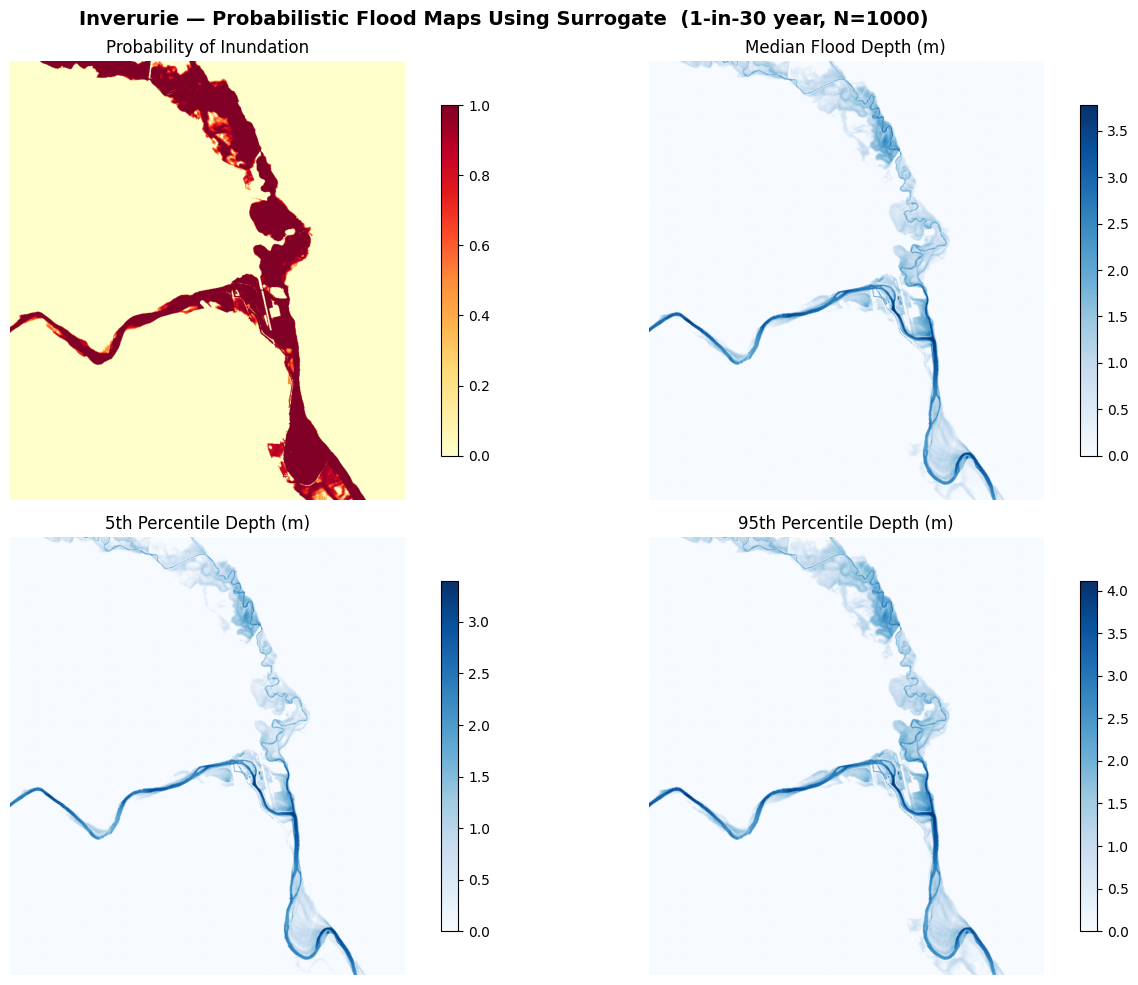

Figure saved.


In [28]:
# Visualise probabilistic flood maps
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# choose joint as default:
prob_inundation = prob_inundation_joint
depth_p05 = depth_p05_joint     
depth_p50 = depth_p50_joint
depth_p95 = depth_p95_joint   

maps = [
    (prob_inundation, 'Probability of Inundation', 'YlOrRd', None),
    (depth_p50,       'Median Flood Depth (m)',     'Blues',  None),
    (depth_p05,       '5th Percentile Depth (m)',   'Blues',  None),
    (depth_p95,       '95th Percentile Depth (m)',  'Blues',  None),
]

for ax, (data, title, cmap, vmax) in zip(axes.flat, maps):
    im = ax.imshow(data, cmap=cmap, origin='upper', vmin=0, vmax=vmax)
    ax.set_title(title, fontsize=12)
    ax.axis('off')
    plt.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle(
    f"{SITE_NAME} — Probabilistic Flood Maps Using Surrogate  (1-in-{RETURN_PERIOD} year, N={N_MC})",
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, f"probabilistic_flood_maps_{RETURN_PERIOD}yr.png"), dpi=150)
plt.show()
print("Figure saved.")

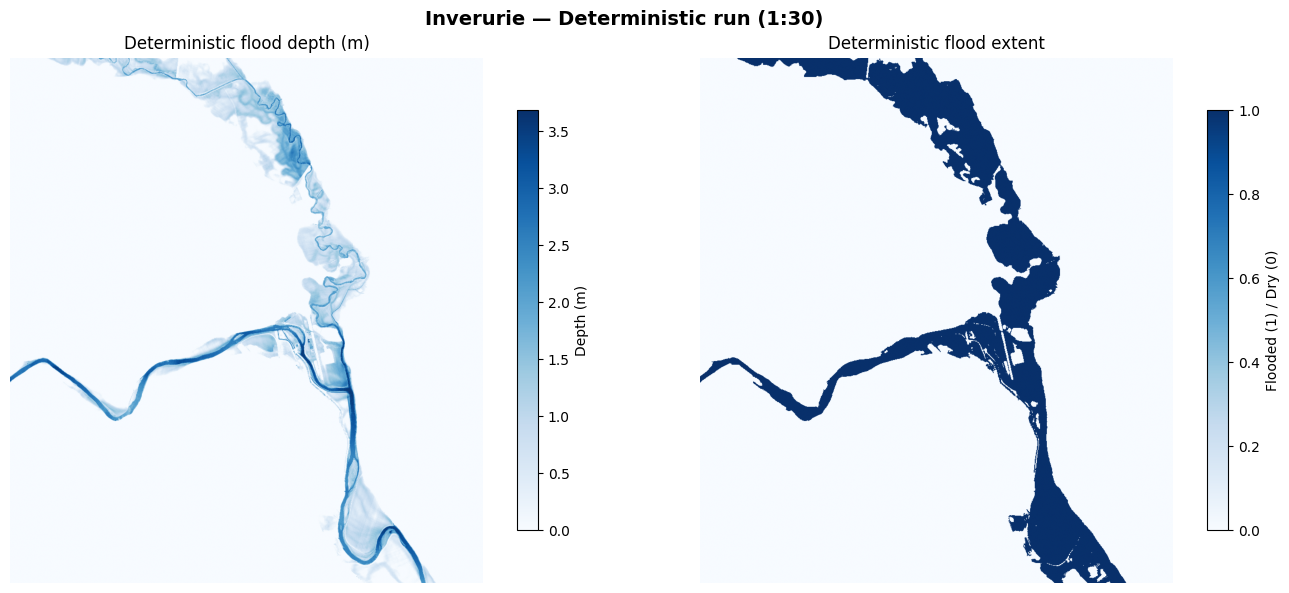

In [29]:
# =========================================
# DETERMINISTIC MAP
# =========================================
det_path = "Z:/inverurie_data/max_maps_FMC/Invervurie_determin.max"
det_map  = process_flood_file(det_path, nrows=NROWS, ncols=NCOLS)
det_wet  = (det_map > 0).astype(np.float32)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Flood depth
im0 = axes[0].imshow(det_map, cmap='Blues', origin='upper', vmin=0)
axes[0].set_title('Deterministic flood depth (m)', fontsize=12)
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], shrink=0.8, label='Depth (m)')

# Wet/dry extent
im1 = axes[1].imshow(det_wet, cmap='Blues', origin='upper', vmin=0, vmax=1)
axes[1].set_title('Deterministic flood extent', fontsize=12)
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], shrink=0.8, label='Flooded (1) / Dry (0)')

fig.suptitle(f"{SITE_NAME} — Deterministic run (1:{RETURN_PERIOD})", fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "deterministic_flood_map.png"), dpi=150)
plt.show()

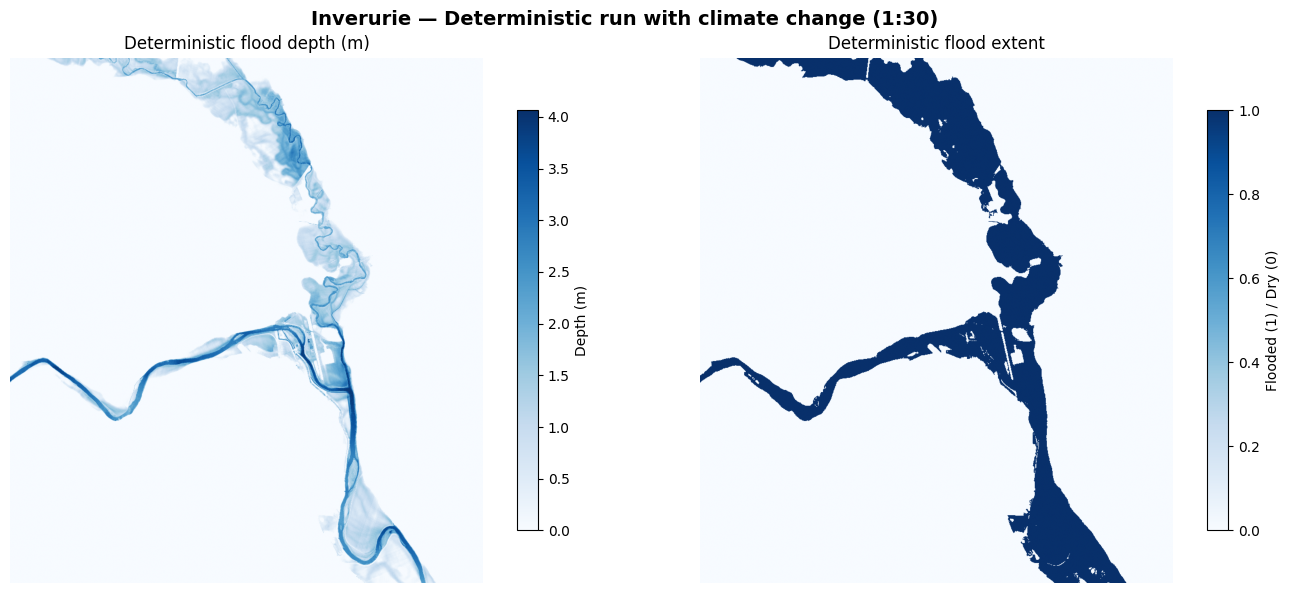

In [30]:
# =========================================
# DETERMINISTIC MAP with climate change
# =========================================
det_path_CC = "Z:/inverurie_data/max_maps_FMC/Invervurie_determin_CC.max"
det_map_CC  = process_flood_file(det_path_CC, nrows=NROWS, ncols=NCOLS)
det_wet_CC  = (det_map_CC > 0).astype(np.float32)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Flood depth
im0 = axes[0].imshow(det_map_CC, cmap='Blues', origin='upper', vmin=0)
axes[0].set_title('Deterministic flood depth (m)', fontsize=12)
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], shrink=0.8, label='Depth (m)')

# Wet/dry extent
im1 = axes[1].imshow(det_wet_CC, cmap='Blues', origin='upper', vmin=0, vmax=1)
axes[1].set_title('Deterministic flood extent', fontsize=12)
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], shrink=0.8, label='Flooded (1) / Dry (0)')

fig.suptitle(f"{SITE_NAME} — Deterministic run with climate change (1:{RETURN_PERIOD})", fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "deterministic_flood_map.png"), dpi=150)
plt.show()

## Prepare for hmtl plot generation

In [32]:
import urllib.request

def _fetch(url):
    with urllib.request.urlopen(url) as r:
        return r.read().decode('utf-8')

print("Fetching Leaflet...")
leaflet_css = _fetch('https://unpkg.com/leaflet@1.9.4/dist/leaflet.css')
leaflet_js  = _fetch('https://unpkg.com/leaflet@1.9.4/dist/leaflet.js')
print("Done.")

Fetching Leaflet...
Done.


In [33]:
def read_lisflood_max(file_path, crs_epsg=27700):
    """
    Read a LISFLOOD-FP .max ASCII-grid file.
    Returns (data_array, extent_dict) where extent is in WGS84 (EPSG:4326).

    The 6-line ASCII header gives us everything we need:
        ncols / nrows      — grid dimensions
        xllcorner          — easting  of the outer SW corner (metres, BNG)
        yllcorner          — northing of the outer SW corner
        cellsize           — cell resolution in metres
        NODATA_value       — no-data sentinel
    """
    with open(file_path, 'r') as f:
        lines = f.readlines()

    header = {}
    for line in lines[:6]:
        key, val = line.strip().split()
        header[key.lower()] = float(val)

    ncols    = int(header['ncols'])
    nrows    = int(header['nrows'])
    xll      = header['xllcorner']
    yll      = header['yllcorner']
    cellsize = header['cellsize']
    nodata   = header.get('nodata_value', -9999)

    print(f"Grid : {nrows} rows × {ncols} cols, cellsize = {cellsize} m")
    print(f"BNG  : x {xll:.1f} → {xll + ncols*cellsize:.1f}, "
          f"y {yll:.1f} → {yll + nrows*cellsize:.1f}")

    # Parse raster data
    flood_data = []
    for line in lines[6:]:
        flood_data.extend([float(v) for v in line.split()])
    arr = np.array(flood_data, dtype=float).reshape((nrows, ncols))
    arr[arr == nodata] = 0.0

    # Native SW/NE corners (xllcorner = outer cell edge, not cell centre)
    x_min, x_max = xll, xll + ncols * cellsize
    y_min, y_max = yll, yll + nrows * cellsize

    # Reproject corners to WGS84
    if crs_epsg == 4326:
        lon_min, lat_min, lon_max, lat_max = x_min, y_min, x_max, y_max
    else:
        t = pyproj.Transformer.from_crs(
            f"EPSG:{crs_epsg}", "EPSG:4326", always_xy=True)
        lon_min, lat_min = t.transform(x_min, y_min)
        lon_max, lat_max = t.transform(x_max, y_max)

    print(f"WGS84: lon {lon_min:.6f} → {lon_max:.6f}, "
          f"lat {lat_min:.6f} → {lat_max:.6f}")

    return arr, dict(
        lon_min=lon_min, lon_max=lon_max,
        lat_min=lat_min, lat_max=lat_max,
        nrows=nrows, ncols=ncols, cellsize=cellsize,
    )

In [34]:
# get extent for map  
_, extent  = read_lisflood_max(det_path, crs_epsg=27700)

Grid : 1000 rows × 900 cols, cellsize = 5.0 m
BNG  : x 375100.0 → 379600.0, y 818200.0 → 823200.0
WGS84: lon -2.414335 → -2.340167, lat 57.253799 → 57.298937


In [37]:
def load_asc(path):
    with open(path) as f:
        lines = f.readlines()
    hdr = {}
    for line in lines[:6]:
        k, v = line.strip().split()
        hdr[k.lower()] = float(v)
    arr = np.loadtxt(path, skiprows=6)
    arr[arr == hdr.get('nodata_value', -9999)] = np.nan
    return arr, hdr['xllcorner'], hdr['yllcorner'], hdr['cellsize']

In [38]:
# load DEM
dem_arr, xll, yll, cs = load_asc("Z:/inverurie_data/5minverurie_dem.asc")

In [41]:
def export_leaflet_html(
    prob_inundation, depth_p05, depth_p50, depth_p95,
    all_mean_maps,
    det_map=None,
    dem_arr=None,
    det_map_CC=None,
    xll=None, yll=None, cs=None,
    site_name="Inverurie",
    return_period=100,
    n_mc=1000,
    lon_min=-2.415, lon_max=-2.345,
    lat_min=57.268, lat_max=57.302,
    overlay_alpha=0.60,
    out_path="flood_explorer.html",
):
    NROWS, NCOLS = prob_inundation.shape
    clat = (lat_min + lat_max) / 2
    clon = (lon_min + lon_max) / 2

    vmax_depth = float(max(
        np.nanmax(depth_p05),
        np.nanmax(depth_p50),
        np.nanmax(depth_p95),
        np.nanmax(det_map) if det_map is not None else 0,
    ))
    print(f"Shared colour scale: 0 → {vmax_depth:.3f} m  (max across all depth layers)")

    dLat = (lat_max - lat_min) / (NROWS - 1)
    dLon = (lon_max - lon_min) / (NCOLS - 1)
    img_lat_min = lat_min - dLat / 2
    img_lat_max = lat_max + dLat / 2
    img_lon_min = lon_min - dLon / 2
    img_lon_max = lon_max + dLon / 2

    PROB_LEVELS = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1.00]
    quant_depths = np.percentile(
        all_mean_maps, [p * 100 for p in PROB_LEVELS], axis=0)

    def _j(arr):
        return json.dumps(np.round(arr.astype(float), 2).tolist())

    det_true_max  = f"{float(np.nanmax(det_map)):.2f}"  if det_map is not None else "null"
    p05_true_max  = f"{float(np.nanmax(depth_p05)):.2f}"
    p50_true_max  = f"{float(np.nanmax(depth_p50)):.2f}"
    p95_true_max  = f"{float(np.nanmax(depth_p95)):.2f}"

    # cross-section data (optional)
    xs_data_js = ""
    xs_btn_html = ""
    if dem_arr is not None and xll is not None:
        det_cc_str = _j(np.maximum(det_map_CC, 0)) if det_map_CC is not None else "null"
        det_str    = _j(np.maximum(det_map,    0)) if det_map    is not None else "null"
        xs_data_js = f"""
const XS_ENABLED = true;
const XLL={xll}, YLL={yll}, CS_M={cs};
const XS_DATA = {{
  dem:    {_j(dem_arr)},
  p05:    {_j(depth_p05)},
  p50:    {_j(depth_p50)},
  p95:    {_j(depth_p95)},
  det:    {det_str},
  det_cc: {det_cc_str},
}};"""
        xs_btn_html = """<button id="xs-btn" style="margin-left:16px;padding:4px 14px;
            background:#0f2236;color:#60a5fa;border:1px solid #1e3a5f;border-radius:5px;
            font-size:12px;cursor:pointer;" title="Toggle cross-section mode">
            ✂ Cross-section</button>"""
    else:
        xs_data_js = "const XS_ENABLED = false;"

    if det_map is not None:
        det_layer_entry = (
            f'"Deterministic (m)":{{data:{_j(np.maximum(det_map, 0))},'
            f'vmin:0,vmax:VMAX_DEPTH,cmap:"Blues",unit:" m"}},'
        )
        det_option = '<option>Deterministic (m)</option><option>Det. + climate change (m)</option>'
        det_card       = f"""
<div class="icard">
  <div class="icard-head">Deterministic run</div>
  <p>Single best-estimate flood depth from the baseline model run using median input
  parameters. No uncertainty is represented — use alongside the probabilistic layers
  to compare the central estimate against the full ensemble spread.</p>
</div>"""
        det_toggle_btn = """
    <hr class="sep">
    <div class="panel-head" style="margin-bottom:6px;">Quick switch</div>
    <div style="display:grid;grid-template-columns:1fr 1fr;gap:6px;">
      <button class="btn btn-active" id="prob-btn">Probabilistic</button>
      <button class="btn" id="det-btn">Deterministic</button>
    </div>"""
    else:
        det_layer_entry = ""
        det_option      = ""
        det_card        = ""
        det_toggle_btn  = ""

    n_info_cols = 6 if det_map is not None else 5

    data_js = f"""
const NROWS={NROWS}, NCOLS={NCOLS};
const LAT_MIN={lat_min}, LAT_MAX={lat_max};
const LON_MIN={lon_min}, LON_MAX={lon_max};
const IMG_LAT_MIN={img_lat_min:.7f}, IMG_LAT_MAX={img_lat_max:.7f};
const IMG_LON_MIN={img_lon_min:.7f}, IMG_LON_MAX={img_lon_max:.7f};
const CLAT={clat}, CLON={clon};
const VMAX_DEPTH={vmax_depth:.4f};
const ALPHA_DEFAULT={overlay_alpha};
const PROB_LEVELS={json.dumps(PROB_LEVELS)};
const QUANT_DEPTHS={_j(quant_depths)};
const LAYERS={{
  {det_layer_entry}
  "Det. + climate change (m)": {{data:{_j(np.maximum(det_map_CC, 0))}, vmin:0, vmax:VMAX_DEPTH, cmap:"Blues", unit:" m"}},
  "P(inundation)":   {{data:{_j(prob_inundation)}, vmin:0, vmax:1,          cmap:"YlOrRd", unit:""}},
  "Median depth (m)":{{data:{_j(depth_p50)},       vmin:0, vmax:VMAX_DEPTH, cmap:"Blues",  unit:" m"}},
  "P05 depth (m)":   {{data:{_j(depth_p05)},       vmin:0, vmax:VMAX_DEPTH, cmap:"Blues",  unit:" m"}},
  "P95 depth (m)":   {{data:{_j(depth_p95)},       vmin:0, vmax:VMAX_DEPTH, cmap:"Blues",  unit:" m"}}
}};
const LAYER_MAXES = {{
  "Deterministic (m)":          {det_true_max},
  "Det. + climate change (m)":  {f"{float(np.nanmax(det_map_CC)):.2f}"},
  "P(inundation)":              null,
  "Median depth (m)":           {p50_true_max},
  "P05 depth (m)":              {p05_true_max},
  "P95 depth (m)":              {p95_true_max}
}};
{xs_data_js}"""

    logic_js = r"""
const CMAPS = {
  YlOrRd: [[255,255,204],[255,237,160],[254,217,118],[254,178,76],
            [253,141,60],[252,78,42],[227,26,28],[189,0,38],[128,0,38]],
  Blues:  [[247,251,255],[222,235,247],[198,219,239],[158,202,225],
            [107,174,214],[66,146,198],[33,113,181],[8,81,156],[8,48,107]]
};
function lerpColor(cmap,t){
  var s=CMAPS[cmap],i=t*(s.length-1),lo=Math.floor(i),
      hi=Math.min(lo+1,s.length-1),f=i-lo;
  return s[lo].map(function(v,k){return Math.round(v+f*(s[hi][k]-v));});
}

var currentLayer='P(inundation)', opacity=ALPHA_DEFAULT;
var depthThresh=0.05, inundThresh=0.0, showLatLon=false, lastClickedCell=null;
var xsMode=false, xsPts=[], xsMarkers=[], xsLine=null, xsYWindow=5;

// ── Map ────────────────────────────────────────────────────────────────────
var map=L.map('map',{center:[CLAT,CLON],zoom:14});
L.tileLayer('https://{s}.basemaps.cartocdn.com/rastertiles/voyager/{z}/{x}/{y}{r}.png',{
  attribution:'&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors &copy; <a href="https://carto.com/attributions">CARTO</a>',
  subdomains:'abcd', maxZoom:20
}).addTo(map);

L.rectangle([[LAT_MIN,LON_MIN],[LAT_MAX,LON_MAX]],{
  color:'#f97316',weight:2,fill:false,dashArray:'10,5',opacity:0.95
}).addTo(map).bindTooltip('Study area boundary',{direction:'top'});

// ── Raster overlay ─────────────────────────────────────────────────────────
var offCanvas=document.createElement('canvas');
offCanvas.width=NCOLS; offCanvas.height=NROWS;
var offCtx=offCanvas.getContext('2d');

function renderCanvas(){
  var lyr=LAYERS[currentLayer];
  var prob=LAYERS['P(inundation)'].data;
  var isDet=(currentLayer==='Deterministic (m)');
  var imgData=offCtx.createImageData(NCOLS,NROWS), px=imgData.data;
  for(var r=0;r<NROWS;r++){
    for(var c=0;c<NCOLS;c++){
      var idx=(r*NCOLS+c)*4, v=lyr.data[r][c];
      var pI=isDet?(v>depthThresh?1:0):prob[r][c];
      if(v===null||(!isDet&&pI<inundThresh)||v<=depthThresh){px[idx+3]=0;continue;}
      var t=Math.min(Math.max((v-lyr.vmin)/(lyr.vmax-lyr.vmin),0),1);
      var col=lerpColor(lyr.cmap,t);
      px[idx]=col[0]; px[idx+1]=col[1]; px[idx+2]=col[2];
      px[idx+3]=Math.round(opacity*255);
    }
  }
  offCtx.putImageData(imgData,0,0);
  return offCanvas.toDataURL();
}

var imgBounds=[[IMG_LAT_MIN,IMG_LON_MIN],[IMG_LAT_MAX,IMG_LON_MAX]];
var overlay=L.imageOverlay(renderCanvas(),imgBounds,
  {opacity:1,interactive:false,zIndex:200}).addTo(map);
function refresh(){overlay.setUrl(renderCanvas());}

// ── Legend ─────────────────────────────────────────────────────────────────
var legend=L.control({position:'topleft'});
legend.onAdd=function(){
  var d=L.DomUtil.create('div','flood-legend');
  d.innerHTML=
    '<div class="leg-title">Map legend</div>'+
    '<div class="leg-sep">Flood likelihood</div>'+
    '<div class="leg-row"><span style="background:#800026"></span>High — &gt;70% chance</div>'+
    '<div class="leg-row"><span style="background:#fd8d3c"></span>Medium — 30–70%</div>'+
    '<div class="leg-row"><span style="background:#ffffcc;outline:1px solid #7a7a5a"></span>Low — &lt;30% chance</div>'+
    '<div class="leg-sep" style="margin-top:8px">Map features</div>'+
    '<div class="leg-row"><span style="background:none;border:2px dashed #f97316;height:0;margin-top:5px;flex-shrink:0"></span>Study area extent</div>';
  return d;
};
var legendOnMap=false;
function syncLegend(){
  if(currentLayer==='P(inundation)'&&!legendOnMap){legend.addTo(map);legendOnMap=true;}
  else if(currentLayer!=='P(inundation)'&&legendOnMap){legend.remove();legendOnMap=false;}
}

// ── Colorbar ───────────────────────────────────────────────────────────────
function drawColorbar(){
  var lyr=LAYERS[currentLayer], cb=document.getElementById('cb-canvas');
  var ctx=cb.getContext('2d');
  for(var x=0;x<cb.width;x++){
    var c=lerpColor(lyr.cmap,x/(cb.width-1));
    ctx.fillStyle='rgb('+c[0]+','+c[1]+','+c[2]+')';
    ctx.fillRect(x,0,1,cb.height);
  }
  document.getElementById('cb-title').textContent=currentLayer;
  document.getElementById('cb-min').textContent=lyr.vmin.toFixed(2)+(lyr.unit||'');
  document.getElementById('cb-max').textContent=lyr.vmax.toFixed(2)+(lyr.unit||'');
  var maxEl=document.getElementById('cb-maxval');
  var mx=LAYER_MAXES[currentLayer];
  maxEl.textContent=(mx!==null&&mx!==undefined)
    ? 'Max for this layer: '+Number(mx).toFixed(2)+' m'
    : '';
}

// ── Helpers ────────────────────────────────────────────────────────────────
function cellToLatLon(r,c){
  return {
    lat: LAT_MAX - r/(NROWS-1)*(LAT_MAX-LAT_MIN),
    lon: LON_MIN + c/(NCOLS-1)*(LON_MAX-LON_MIN)
  };
}
function cellLabel(r,c){
  if(showLatLon){
    var ll=cellToLatLon(r,c);
    return 'Lat\u00a0'+ll.lat.toFixed(5)+',\u00a0Lon\u00a0'+ll.lon.toFixed(5);
  }
  return 'Row\u00a0'+r+',\u00a0Col\u00a0'+c;
}

// ── Depth exceedance chart ─────────────────────────────────────────────────
function drawExceedance(r,c){
  document.getElementById('exc-prompt').style.display='none';
  var canvas=document.getElementById('exc-canvas');
  canvas.style.display='block';
  canvas.width  = canvas.offsetWidth  || 264;
  canvas.height = canvas.offsetHeight || 200;
  document.getElementById('exc-subtitle').textContent=cellLabel(r,c);
  var depths=[], excProbs=[];
  for(var i=0;i<PROB_LEVELS.length;i++){
    depths.push(QUANT_DEPTHS[i][r][c]);
    excProbs.push(1-PROB_LEVELS[i]);
  }
  var ctx=canvas.getContext('2d'), W=canvas.width, H=canvas.height;
  var pad={t:24,r:14,b:58,l:50}, pw=W-pad.l-pad.r, ph=H-pad.t-pad.b;
  ctx.clearRect(0,0,W,H);
  ctx.fillStyle='#0a1220'; ctx.fillRect(0,0,W,H);
  var xMax=Math.max(depths[depths.length-1]*1.1,0.01);
  if(depths[Math.floor(depths.length/2)]<0.001){
    ctx.fillStyle='#475569'; ctx.font='15px Segoe UI,Arial';
    ctx.textAlign='center';
    ctx.fillText('No significant flooding at this cell',W/2,H/2);
    return;
  }
  ctx.strokeStyle='#1e293b'; ctx.lineWidth=0.5;
  [0,0.2,0.4,0.6,0.8,1.0].forEach(function(f){
    var y=pad.t+(1-f)*ph;
    ctx.beginPath(); ctx.moveTo(pad.l,y); ctx.lineTo(pad.l+pw,y); ctx.stroke();
  });
  [0,0.25,0.5,0.75,1].forEach(function(f){
    var x=pad.l+f*pw;
    ctx.beginPath(); ctx.moveTo(x,pad.t); ctx.lineTo(x,pad.t+ph); ctx.stroke();
  });
  ctx.strokeStyle='#334155'; ctx.lineWidth=1;
  ctx.beginPath();
  ctx.moveTo(pad.l,pad.t); ctx.lineTo(pad.l,pad.t+ph); ctx.lineTo(pad.l+pw,pad.t+ph);
  ctx.stroke();
  ctx.beginPath();
  ctx.moveTo(pad.l+(depths[0]/xMax)*pw,pad.t+(1-excProbs[0])*ph);
  for(var i=1;i<depths.length;i++)
    ctx.lineTo(pad.l+(depths[i]/xMax)*pw,pad.t+(1-excProbs[i])*ph);
  ctx.lineTo(pad.l+(depths[depths.length-1]/xMax)*pw,pad.t+ph);
  ctx.lineTo(pad.l+(depths[0]/xMax)*pw,pad.t+ph);
  ctx.closePath();
  ctx.fillStyle='rgba(59,130,246,0.12)'; ctx.fill();
  ctx.strokeStyle='#3b82f6'; ctx.lineWidth=2; ctx.beginPath();
  for(var i=0;i<depths.length;i++){
    var x=pad.l+(depths[i]/xMax)*pw, y=pad.t+(1-excProbs[i])*ph;
    i===0?ctx.moveTo(x,y):ctx.lineTo(x,y);
  }
  ctx.stroke();
  if(typeof LAYERS['Deterministic (m)']!=='undefined'){
    var vdet=LAYERS['Deterministic (m)'].data[r][c];
    if(vdet>0.001){
      var xdet=pad.l+(vdet/xMax)*pw;
      ctx.strokeStyle='#60a5fa'; ctx.lineWidth=1.5; ctx.setLineDash([4,3]);
      ctx.beginPath(); ctx.moveTo(xdet,pad.t); ctx.lineTo(xdet,pad.t+ph); ctx.stroke();
      ctx.setLineDash([]);
      ctx.fillStyle='#60a5fa'; ctx.font='bold 12px Segoe UI,Arial'; ctx.textAlign='left';
      ctx.fillText('Det.',xdet+3,pad.t+10);
      ctx.font='12px Segoe UI,Arial';
      ctx.fillText(vdet.toFixed(2)+'m',xdet+3,pad.t+21);
    }
  }
  var markers=[
    {p:0.05, col:'#fbbf24', lbl:'P95'},
    {p:0.50, col:'#34d399', lbl:'Median'},
    {p:0.95, col:'#f87171', lbl:'P05'}
  ];
  markers.forEach(function(m){
    var pi=PROB_LEVELS.indexOf(m.p);
    m.d  =pi>=0?depths[pi]:0;
    m.exc=pi>=0?excProbs[pi]:0;
    m.px =pad.l+(m.d/xMax)*pw;
    m.py =pad.t+(1-m.exc)*ph;
  });
  var sorted=markers.slice().sort(function(a,b){return a.px-b.px;});
  var MIN_GAP=38;
  sorted[0].row=0;
  for(var i=1;i<sorted.length;i++){
    sorted[i].row=(sorted[i].px-sorted[i-1].px<MIN_GAP)?1-sorted[i-1].row:0;
  }
  var rowY=[pad.t+ph+14,pad.t+ph+32];
  markers.forEach(function(m){
    ctx.strokeStyle=m.col; ctx.lineWidth=0.8; ctx.setLineDash([3,3]);
    ctx.beginPath(); ctx.moveTo(m.px,pad.t+ph); ctx.lineTo(m.px,m.py); ctx.stroke();
    ctx.beginPath(); ctx.moveTo(pad.l,m.py); ctx.lineTo(m.px,m.py); ctx.stroke();
    ctx.setLineDash([]);
    ctx.fillStyle=m.col;
    ctx.beginPath(); ctx.arc(m.px,m.py,3.5,0,2*Math.PI); ctx.fill();
    ctx.strokeStyle=m.col; ctx.lineWidth=1;
    ctx.beginPath(); ctx.moveTo(m.px,pad.t+ph); ctx.lineTo(m.px,pad.t+ph+5); ctx.stroke();
    var ly=rowY[m.row];
    ctx.strokeStyle=m.col; ctx.lineWidth=0.5; ctx.setLineDash([2,2]);
    ctx.beginPath(); ctx.moveTo(m.px,pad.t+ph+5); ctx.lineTo(m.px,ly-10); ctx.stroke();
    ctx.setLineDash([]);
    ctx.fillStyle=m.col; ctx.font='bold 12px Segoe UI,Arial'; ctx.textAlign='center';
    ctx.fillText(m.lbl,m.px,ly);
    ctx.font='12px Segoe UI,Arial';
    ctx.fillText(m.d.toFixed(2)+'m',m.px,ly+11);
  });
  ctx.fillStyle='#94a3b8'; ctx.font='13px Segoe UI,Arial';
  [0,0.2,0.4,0.6,0.8,1.0].forEach(function(f){
    ctx.textAlign='right';
    ctx.fillText(f.toFixed(1),pad.l-5,pad.t+(1-f)*ph+3.5);
  });
  [0,0.25,0.5,0.75,1].forEach(function(f){
    ctx.textAlign='center';
    ctx.fillText((f*xMax).toFixed(2),pad.l+f*pw,pad.t+ph+10);
  });
  ctx.fillStyle='#cbd5e1'; ctx.font='14px Segoe UI,Arial'; ctx.textAlign='center';
  ctx.fillText('Depth (m)',pad.l+pw/2,H-1);
  ctx.save(); ctx.translate(12,pad.t+ph/2); ctx.rotate(-Math.PI/2);
  ctx.fillText('P(depth exceeded)',0,0); ctx.restore();
  ctx.fillStyle='#334155'; ctx.font='12px Segoe UI,Arial'; ctx.textAlign='right';
  ctx.fillText('Empirical — N='+PROB_LEVELS.length+' quantile levels',W-4,pad.t-5);
}

// ── Cross-section mode ─────────────────────────────────────────────────────
function latLonToRowCol(lat,lon){
  var r=Math.min(Math.max(Math.round((LAT_MAX-lat)/(LAT_MAX-LAT_MIN)*(NROWS-1)),0),NROWS-1);
  var c=Math.min(Math.max(Math.round((lon-LON_MIN)/(LON_MAX-LON_MIN)*(NCOLS-1)),0),NCOLS-1);
  var x=XLL+c*CS_M, y=YLL+(NROWS-1-r)*CS_M;
  return {r:r,c:c,x:x,y:y};
}

function sampleAlongLine(key,r0,c0,r1,c1,n){
  var vals=[];
  for(var i=0;i<n;i++){
    var t=i/(n-1);
    var r=Math.round(r0+t*(r1-r0)), c=Math.round(c0+t*(c1-c0));
    if(r>=0&&r<NROWS&&c>=0&&c<NCOLS){
      var v=XS_DATA[key][r][c];
      vals.push(v===null?NaN:v);
    } else vals.push(NaN);
  }
  return vals;
}

function drawXsProfile(p0,p1){
  var dx=p1.x-p0.x, dy=p1.y-p0.y;
  var lenM=Math.sqrt(dx*dx+dy*dy);
  var n=Math.max(Math.ceil(lenM/CS_M),2);

  var dem   =sampleAlongLine('dem',   p0.r,p0.c,p1.r,p1.c,n);
  var p05   =sampleAlongLine('p05',   p0.r,p0.c,p1.r,p1.c,n);
  var p50   =sampleAlongLine('p50',   p0.r,p0.c,p1.r,p1.c,n);
  var p95   =sampleAlongLine('p95',   p0.r,p0.c,p1.r,p1.c,n);
  var det   =sampleAlongLine('det',   p0.r,p0.c,p1.r,p1.c,n);
  var det_cc=sampleAlongLine('det_cc',p0.r,p0.c,p1.r,p1.c,n);

  function wseC(d,dp){ return isNaN(d)?NaN:d+Math.max(dp||0,0); }
  function wseG(d,dp){ return (isNaN(d)||!dp||dp<=0)?NaN:d+dp; }

  var p05w=dem.map(function(d,i){return wseC(d,p05[i]);});
  var p50w=dem.map(function(d,i){return wseC(d,p50[i]);});
  var p95w=dem.map(function(d,i){return wseC(d,p95[i]);});
  var detw=dem.map(function(d,i){return wseG(d,det[i]);});
  var dccw=dem.map(function(d,i){return wseG(d,det_cc[i]);});

  var validDem=dem.filter(function(v){return !isNaN(v);});
  var meanElev=validDem.reduce(function(a,b){return a+b;},0)/validDem.length;
  var yw=xsYWindow;
  var yMin=meanElev-yw, yMax=meanElev+yw;

  var canvas=document.getElementById('xs-canvas');
  canvas.width=canvas.offsetWidth||500;
  canvas.height=canvas.offsetHeight||300;
  var ctx=canvas.getContext('2d');
  var W=canvas.width, H=canvas.height;
  var pad={t:28,r:20,b:48,l:55}, pw=W-pad.l-pad.r, ph=H-pad.t-pad.b;

  ctx.clearRect(0,0,W,H);
  ctx.fillStyle='#0a1220'; ctx.fillRect(0,0,W,H);

  function px(i){return pad.l+(i/(n-1))*pw;}
  function py(v){return pad.t+(1-(v-yMin)/(yMax-yMin))*ph;}
  function clampY(v){return Math.max(pad.t,Math.min(pad.t+ph,py(v)));}

  // gridlines
  ctx.strokeStyle='#1e293b'; ctx.lineWidth=0.5;
  for(var gi=0;gi<=4;gi++){
    var gv=yMin+gi/4*(yMax-yMin), gyp=py(gv);
    ctx.beginPath(); ctx.moveTo(pad.l,gyp); ctx.lineTo(pad.l+pw,gyp); ctx.stroke();
  }

  // DEM fill
  ctx.beginPath();
  var fs=false;
  for(var i=0;i<n;i++){
    if(isNaN(dem[i])) continue;
    if(!fs){ctx.moveTo(px(i),pad.t+ph); ctx.lineTo(px(i),clampY(dem[i])); fs=true;}
    else ctx.lineTo(px(i),clampY(dem[i]));
  }
  ctx.lineTo(px(n-1),pad.t+ph); ctx.closePath();
  ctx.fillStyle='rgba(160,82,45,0.25)'; ctx.fill();

  // p05–p95 envelope
  ctx.beginPath(); fs=false;
  for(var i=0;i<n;i++){
    if(isNaN(p95w[i])) continue;
    if(!fs){ctx.moveTo(px(i),clampY(p95w[i])); fs=true;}
    else ctx.lineTo(px(i),clampY(p95w[i]));
  }
  for(var i=n-1;i>=0;i--){
    if(!isNaN(p05w[i])) ctx.lineTo(px(i),clampY(p05w[i]));
  }
  ctx.closePath();
  ctx.fillStyle='rgba(59,130,246,0.2)'; ctx.fill();

  function drawLine(vals,color,width,dash){
    ctx.strokeStyle=color; ctx.lineWidth=width; ctx.setLineDash(dash||[]);
    ctx.beginPath(); var s=false;
    for(var i=0;i<n;i++){
      if(isNaN(vals[i])){s=false;continue;}
      var yp=clampY(vals[i]);
      if(!s){ctx.moveTo(px(i),yp);s=true;}else ctx.lineTo(px(i),yp);
    }
    ctx.stroke(); ctx.setLineDash([]);
  }

  drawLine(dem,  '#a0522d',1.5);
  drawLine(p50w, '#3b82f6',2.0);
  drawLine(detw, '#e2e8f0',2.0);
  drawLine(dccw, '#ef4444',2.0,[6,3]);

  // axes
  ctx.strokeStyle='#334155'; ctx.lineWidth=1;
  ctx.beginPath();
  ctx.moveTo(pad.l,pad.t); ctx.lineTo(pad.l,pad.t+ph); ctx.lineTo(pad.l+pw,pad.t+ph);
  ctx.stroke();

  // y labels
  ctx.fillStyle='#94a3b8'; ctx.font='14px Segoe UI,Arial'; ctx.textAlign='right';
  for(var gi=0;gi<=4;gi++){
    var gv=yMin+gi/4*(yMax-yMin);
    ctx.fillText(gv.toFixed(1),pad.l-5,py(gv)+4);
  }
  // x labels
  ctx.textAlign='center';
  for(var xi=0;xi<=4;xi++){
    ctx.fillText((xi/4*lenM).toFixed(0)+'m',pad.l+xi/4*pw,pad.t+ph+14);
  }
  // axis titles
  ctx.fillStyle='#cbd5e1'; ctx.font='14px Segoe UI,Arial'; ctx.textAlign='center';
  ctx.fillText('Distance (m)',pad.l+pw/2,H-2);
  ctx.save(); ctx.translate(14,pad.t+ph/2); ctx.rotate(-Math.PI/2);
  ctx.fillText('Elevation (m AOD)',0,0); ctx.restore();

  // title
  ctx.fillStyle='#f1f5f9'; ctx.font='14px Segoe UI,Arial'; ctx.textAlign='left';
  ctx.fillText(lenM.toFixed(0)+'m  |  angle: '+Math.round(Math.atan2(dy,dx)*180/Math.PI)+'°',pad.l,18);

    // ── Human figure for scale ────────────────────────────────────────────────
      var humanHeight = 1.8; // metres
      var humanX = pad.l + pw * 0.97;  // right side of profile
      var humanBaseY = py(meanElev);   // stand on mean ground level
      var humanTopY  = py(meanElev + humanHeight);
      var humanPx    = humanTopY - humanBaseY; // pixel height of human
    
      // Only draw if human fits in the plot
      if (humanBaseY <= pad.t + ph && humanTopY >= pad.t) {
        var hx = humanX;
        var hBase = Math.min(humanBaseY, pad.t + ph);
        var hTop  = Math.max(humanTopY,  pad.t);
        var hMid  = (hBase + hTop) / 2;
        var hPx   = hBase - hTop; // pixel height available
    
        ctx.strokeStyle = '#f59e0b';
        ctx.fillStyle   = '#f59e0b';
        ctx.lineWidth   = 1.5;
    
        // head (circle)
        var headR = Math.max(hPx * 0.13, 3);
        ctx.beginPath();
        ctx.arc(hx, hTop + headR, headR, 0, 2 * Math.PI);
        ctx.fill();
    
        // body
        var neckY  = hTop + headR * 2;
        var waistY = hTop + hPx * 0.55;
        ctx.beginPath(); ctx.moveTo(hx, neckY); ctx.lineTo(hx, waistY); ctx.stroke();
    
        // arms
        var armY = hTop + hPx * 0.38;
        ctx.beginPath(); ctx.moveTo(hx - hPx*0.18, armY); ctx.lineTo(hx + hPx*0.18, armY); ctx.stroke();
    
        // legs
        ctx.beginPath(); ctx.moveTo(hx, waistY); ctx.lineTo(hx - hPx*0.14, hBase); ctx.stroke();
        ctx.beginPath(); ctx.moveTo(hx, waistY); ctx.lineTo(hx + hPx*0.14, hBase); ctx.stroke();
    
        // label
        ctx.fillStyle   = '#f59e0b';
        ctx.font        = '10px Segoe UI,Arial';
        ctx.textAlign   = 'center';
        ctx.fillText('1.8m', hx, hBase + 12);
      }

  // legend
  var leg=[
    ['#a0522d','DEM',[]],['#3b82f6','Emulator p50',[]],
    ['rgba(59,130,246,0.35)','p05–p95',[]],
    ['#e2e8f0','Deterministic',[]],['#ef4444','Det.+CC',[5,3]]
  ];
  var lx=pad.l, ly2=pad.t+ph+30;
  ctx.font='13px Segoe UI,Arial';
  leg.forEach(function(l){
    ctx.strokeStyle=l[0]; ctx.lineWidth=2; ctx.setLineDash(l[2]);
    ctx.beginPath(); ctx.moveTo(lx,ly2); ctx.lineTo(lx+16,ly2); ctx.stroke();
    ctx.setLineDash([]);
    ctx.fillStyle='#94a3b8'; ctx.textAlign='left';
    ctx.fillText(l[1],lx+20,ly2+4);
    lx+=ctx.measureText(l[1]).width+36;
  });

  document.getElementById('xs-status').textContent=
    'Length: '+lenM.toFixed(0)+'m  ·  Click START to draw new line';
}

function toggleXsMode(){
  if(!XS_ENABLED) return;
  xsMode=!xsMode;
  var btn=document.getElementById('xs-btn');
  var panel=document.getElementById('xs-panel');
  var excPanel=document.getElementById('exc-panel');
  if(xsMode){
    btn.style.background='#1e3a5f'; btn.style.color='#93c5fd';
    panel.style.display='block';
    if(!panel.style.top || panel.style.top===''){
      panel.style.left=Math.round((window.innerWidth-panel.offsetWidth)/2)+'px';
      panel.style.top =(window.innerHeight-panel.offsetHeight-20)+'px';
    }
    excPanel.style.display='none';
    document.getElementById('xs-status').textContent='Click START point on the map';
    map.getContainer().style.cursor='crosshair';
    // clear any previous
    xsPts=[]; xsMarkers.forEach(function(m){map.removeLayer(m);}); xsMarkers=[];
    if(xsLine){map.removeLayer(xsLine); xsLine=null;}
  } else {
    btn.style.background=''; btn.style.color='';
    panel.style.display='none';
    excPanel.style.display='block';
    map.getContainer().style.cursor='';
    xsPts=[]; xsMarkers.forEach(function(m){map.removeLayer(m);}); xsMarkers=[];
    if(xsLine){map.removeLayer(xsLine); xsLine=null;}
  }
}

// ── Map click ──────────────────────────────────────────────────────────────
map.on('click',function(e){
  var lat=e.latlng.lat, lon=e.latlng.lng;
  if(lat<LAT_MIN||lat>LAT_MAX||lon<LON_MIN||lon>LON_MAX) return;

  if(xsMode){
    // cross-section click handling
    var pt=latLonToRowCol(lat,lon);

    if(xsPts.length===0 || xsPts.length===2){
      // reset and set start
      xsPts=[]; xsMarkers.forEach(function(m){map.removeLayer(m);}); xsMarkers=[];
      if(xsLine){map.removeLayer(xsLine); xsLine=null;}
      xsPts.push(pt);
      xsMarkers.push(L.circleMarker([lat,lon],
        {radius:7,color:'#22c55e',fillColor:'#22c55e',fillOpacity:1,zIndex:500}).addTo(map));
      document.getElementById('xs-status').textContent=
        'START set — now click END point';
    } else if(xsPts.length===1){
      xsPts.push(pt);
      xsMarkers.push(L.circleMarker([lat,lon],
        {radius:7,color:'#ef4444',fillColor:'#ef4444',fillOpacity:1,zIndex:500}).addTo(map));
      var ll0=cellToLatLon(xsPts[0].r,xsPts[0].c);
      xsLine=L.polyline([[ll0.lat,ll0.lon],[lat,lon]],
        {color:'#ef4444',weight:2,dashArray:'6,4'}).addTo(map);
      document.getElementById('xs-status').textContent='Drawing...';
      drawXsProfile(xsPts[0],xsPts[1]);
    }
    return;
  }

  // normal click — exceedance curve
  var r=Math.min(Math.max(Math.round((LAT_MAX-lat)/(LAT_MAX-LAT_MIN)*(NROWS-1)),0),NROWS-1);
  var c=Math.min(Math.max(Math.round((lon-LON_MIN)/(LON_MAX-LON_MIN)*(NCOLS-1)),0),NCOLS-1);
  lastClickedCell={r:r,c:c};
  var vp =LAYERS['P(inundation)'].data[r][c];
  var v50=LAYERS['Median depth (m)'].data[r][c];
  var v05=LAYERS['P05 depth (m)'].data[r][c];
  var v95=LAYERS['P95 depth (m)'].data[r][c];
  var ll =cellToLatLon(r,c);
  var vdet=(typeof LAYERS['Deterministic (m)']!=='undefined')
           ?LAYERS['Deterministic (m)'].data[r][c]:null;
  var detRow=vdet!==null
    ?'<div class="pr"><span class="pk">Det. depth</span>'+
     '<span class="pv" style="color:#60a5fa;">'+vdet.toFixed(3)+' m</span></div>'
    :'';
  L.popup({maxWidth:250}).setLatLng(e.latlng).setContent(
    '<div style="padding:4px 2px;min-width:195px;">'+
    '<div style="font-weight:600;margin-bottom:7px;color:#e2e8f0;font-size:13px;">'+cellLabel(r,c)+'</div>'+
    '<div class="pr"><span class="pk">Lat / Lon</span>'+
      '<span class="pv" style="font-size:11px;">'+ll.lat.toFixed(5)+', '+ll.lon.toFixed(5)+'</span></div>'+
    '<div class="pr"><span class="pk">P(inundation)</span><span class="pv">'+vp.toFixed(3)+'</span></div>'+
    detRow+
    '<div class="pr"><span class="pk">Median depth</span><span class="pv">'+v50.toFixed(3)+' m</span></div>'+
    '<div class="pr"><span class="pk">P05 depth</span><span class="pv">'+v05.toFixed(3)+' m</span></div>'+
    '<div class="pr"><span class="pk">P95 depth</span><span class="pv">'+v95.toFixed(3)+' m</span></div>'+
    '<div style="margin-top:7px;padding-top:5px;border-top:1px solid #1e293b;color:#475569;font-size:11px;">'+
      'Uncertainty range: '+(v95-v05).toFixed(3)+' m</div>'+
    '</div>'
  ).openOn(map);
  drawExceedance(r,c);
});

// ── Controls ───────────────────────────────────────────────────────────────
document.getElementById('layer-select').addEventListener('change',function(e){
  currentLayer=e.target.value; syncLegend(); drawColorbar(); refresh(); syncToggleBtns();
});
document.getElementById('opacity-slider').addEventListener('input',function(e){
  opacity=+e.target.value/100;
  document.getElementById('opacity-val').textContent=e.target.value; refresh();
});
document.getElementById('inund-slider').addEventListener('input',function(e){
  inundThresh=+e.target.value/100;
  document.getElementById('inund-val').textContent=e.target.value; refresh();
});
document.getElementById('depth-slider').addEventListener('input',function(e){
  depthThresh=+e.target.value;
  document.getElementById('depth-val').textContent=(+e.target.value).toFixed(2); refresh();
});
document.getElementById('coord-toggle').addEventListener('click',function(){
  showLatLon=!showLatLon;
  this.textContent=showLatLon?'Show row / col':'Show lat / lon';
  if(lastClickedCell)
    document.getElementById('exc-subtitle').textContent=
      cellLabel(lastClickedCell.r,lastClickedCell.c);
});
var infoOpen=true;
document.getElementById('info-toggle').addEventListener('click',function(){
  infoOpen=!infoOpen;
  document.getElementById('info-content').style.display=infoOpen?'grid':'none';
  document.getElementById('tog-arrow').textContent=infoOpen?'▼':'▲';
});
var probBtn=document.getElementById('prob-btn');
var detBtn =document.getElementById('det-btn');
function syncToggleBtns(){
  if(!probBtn||!detBtn) return;
  var isDet=(currentLayer==='Deterministic (m)');
  probBtn.className='btn'+(isDet?'':' btn-active');
  detBtn.className ='btn'+(isDet?' btn-active':'');
}
if(probBtn&&detBtn){
  probBtn.addEventListener('click',function(){
    currentLayer='P(inundation)';
    document.getElementById('layer-select').value='P(inundation)';
    syncLegend(); drawColorbar(); refresh(); syncToggleBtns();
  });
  detBtn.addEventListener('click',function(){
    currentLayer='Deterministic (m)';
    document.getElementById('layer-select').value='Deterministic (m)';
    syncLegend(); drawColorbar(); refresh(); syncToggleBtns();
  });
}

// y-window slider for cross-section
document.getElementById('xs-yw-slider').addEventListener('input',function(){
  xsYWindow=parseFloat(this.value);
  document.getElementById('xs-yw-val').textContent=this.value;
  if(xsPts.length===2) drawXsProfile(xsPts[0],xsPts[1]);
});

if(XS_ENABLED){
  document.getElementById('xs-btn').addEventListener('click', toggleXsMode);
  document.getElementById('xs-save-btn').addEventListener('click',function(){
    var a=document.createElement('a');
    a.download='cross_section.png';
    a.href=document.getElementById('xs-canvas').toDataURL();
    a.click();
  });
  document.getElementById('xs-close-btn').addEventListener('click', toggleXsMode);
  document.getElementById('xs-redraw-btn').addEventListener('click', function(){
    if(xsPts.length===2) drawXsProfile(xsPts[0], xsPts[1]);
  });
}

document.getElementById('exc-redraw-btn').addEventListener('click', function(){
  if(lastClickedCell) drawExceedance(lastClickedCell.r, lastClickedCell.c);
});

drawColorbar(); syncLegend(); syncToggleBtns();

// ── Draggable panels ───────────────────────────────────────────────────────
function makeDraggable(panelId, handleId){
  var panel=document.getElementById(panelId);
  var handle=document.getElementById(handleId);
  if(!panel||!handle) return;
  var dragging=false,startX,startY,origLeft,origTop;
  handle.addEventListener('mousedown',function(e){
    // don't drag if user clicked the close button
    if(e.target.closest && e.target.closest('button')) return;
    dragging=true;
    startX=e.clientX; startY=e.clientY;
    origLeft=parseInt(panel.style.left)||panel.getBoundingClientRect().left;
    origTop =parseInt(panel.style.top) ||panel.getBoundingClientRect().top;
    handle.style.cursor='grabbing'; e.preventDefault();
  });
  document.addEventListener('mousemove',function(e){
    if(!dragging) return;
    panel.style.left=Math.min(Math.max(origLeft+(e.clientX-startX),0),window.innerWidth -panel.offsetWidth)+'px';
    panel.style.top =Math.min(Math.max(origTop +(e.clientY-startY),0),window.innerHeight-panel.offsetHeight)+'px';
  });
  document.addEventListener('mouseup',function(){
    if(!dragging) return; dragging=false; handle.style.cursor='grab';
  });
}

makeDraggable('exc-panel','exc-drag-handle');
makeDraggable('xs-panel','xs-drag-handle');

// position exc panel bottom-right on load
requestAnimationFrame(function(){
  var p=document.getElementById('exc-panel');
  p.style.left=(window.innerWidth -p.offsetWidth -20)+'px';
  p.style.top =(window.innerHeight-p.offsetHeight-60)+'px';
});
"""

    info_cards = f"""
<div class="icard">
  <div class="icard-head">Probability of inundation</div>
  <p>The chance a location floods during a 1-in-{return_period} yr event, from {n_mc:,} simulations
  sampling uncertainty in rainfall and catchment response. 0.9 = flooded in 9 of 10 runs.
  Pale yellow = low risk; deep red = high risk (&gt;70%).</p>
</div>
<div class="icard">
  <div class="icard-head">Median depth</div>
  <p>The 50th-percentile flood depth across {n_mc:,} simulations. Half predicted shallower,
  half deeper. Best single-number summary for general flood-risk communication.</p>
</div>
<div class="icard">
  <div class="icard-head">P05 — optimistic scenario</div>
  <p>Near best-case: only 5% of runs predicted shallower flooding. Illustrates the
  lower-bound plausible impact. Not suitable for planning or design.</p>
</div>
<div class="icard">
  <div class="icard-head">P95 — precautionary scenario</div>
  <p>Near worst-case: only 5% of runs predicted deeper flooding. Use for critical
  infrastructure, vulnerable properties, insurance, or emergency planning.</p>
</div>
<div class="icard">
  <div class="icard-head">Depth exceedance curve</div>
  <p>Click any cell to see the full depth-uncertainty distribution at that point.
  Empirical P(depth &gt; d) vs d computed directly from all {n_mc:,} model runs —
  no distributional assumption. Blue dashed line shows the deterministic depth.</p>
</div>
{det_card}"""

    html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width,initial-scale=1.0">
<title>{site_name} — 1-in-{return_period} yr flood explorer</title>
<style>{leaflet_css}</style>
<script>{leaflet_js}</script>
<style>
:root{{
  --fs-xs:  clamp(11px, 1.2vw, 16px);
  --fs-sm:  clamp(13px, 1.4vw, 19px);
  --fs-md:  clamp(14px, 1.6vw, 22px);
}}
*{{box-sizing:border-box;margin:0;padding:0;}}
body{{font-family:'Segoe UI',Arial,sans-serif;font-size:var(--fs-sm);background:#0f172a;
     color:#e2e8f0;display:flex;flex-direction:column;height:100vh;overflow:hidden;}}
#hdr{{padding:9px 18px;background:#1e293b;border-bottom:1px solid #334155;
      display:flex;align-items:center;justify-content:space-between;flex-shrink:0;}}
#hdr h1{{font-size:var(--fs-md);font-weight:600;color:#f1f5f9;}}
#hdr span{{font-size:var(--fs-xs);color:#64748b;}}
#map-wrap{{flex:1;position:relative;min-height:0;}}
#map{{width:100%;height:100%;}}
.panel{{position:absolute;z-index:1000;background:rgba(10,18,35,0.93);
        border:1px solid #1e3a5f;border-radius:9px;backdrop-filter:blur(8px);
        overflow:hidden;}}
.panel-head{{font-size:var(--fs-xs);text-transform:uppercase;letter-spacing:.08em;
             color:#4a7fb5;margin-bottom:10px;font-weight:600;}}
#ctrl-panel{{top:10px;right:10px;padding:14px 16px;width:270px;}}
.ctrl{{margin-bottom:10px;}}
.ctrl label{{display:block;color:#94a3b8;font-size:var(--fs-xs);margin-bottom:4px;}}
.ctrl label b{{color:#cbd5e1;font-weight:600;}}
.ctrl select{{width:100%;background:#0f2236;color:#e2e8f0;border:1px solid #1e3a5f;
              border-radius:5px;padding:6px 9px;font-size:var(--fs-sm);cursor:pointer;appearance:none;}}
.ctrl input[type=range]{{width:100%;accent-color:#3b82f6;cursor:pointer;margin-top:2px;}}
.sep{{border:none;border-top:1px solid #1a2a3a;margin:10px 0;}}
.ctrl-note{{font-size:var(--fs-xs);color:#334155;margin-top:3px;}}
.btn{{width:100%;margin-top:4px;padding:6px 9px;background:#0f2236;color:#60a5fa;
      border:1px solid #1e3a5f;border-radius:5px;font-size:var(--fs-xs);cursor:pointer;
      transition:background 0.15s;}}
.btn:hover{{background:#162032;}}
.btn-active{{background:#1e3a5f !important;color:#93c5fd !important;border-color:#3b82f6 !important;}}
#cb-panel{{top:10px;left:10px;padding:10px 14px;width:185px;}}
#cb-canvas{{width:100%;height:12px;border-radius:3px;display:block;}}
#cb-labels{{display:flex;justify-content:space-between;font-size:var(--fs-xs);color:#4a7fb5;margin-top:4px;}}
#cb-maxval{{font-size:var(--fs-xs);color:#64748b;margin-top:5px;text-align:right;
            padding-top:4px;border-top:1px solid #1e3a5f;}}
.flood-legend{{background:rgba(10,18,35,0.93)!important;border:1px solid #1e3a5f!important;
               border-radius:9px;padding:11px 14px!important;margin-top:100px!important;}}
.leg-title{{font-size:var(--fs-xs);text-transform:uppercase;letter-spacing:.08em;color:#4a7fb5;
            font-weight:600;margin-bottom:8px;}}
.leg-sep{{font-size:var(--fs-xs);color:#334155;margin:6px 0 5px;text-transform:uppercase;letter-spacing:.05em;}}
.leg-row{{display:flex;align-items:center;gap:8px;font-size:var(--fs-sm);color:#94a3b8;margin-bottom:5px;}}
.leg-row span{{width:20px;height:11px;border-radius:2px;flex-shrink:0;display:inline-block;}}
#exc-panel{{top:10px;left:10px;padding:0;width:290px;user-select:none;
            resize:both;overflow:auto;min-width:200px;min-height:150px;}}
#exc-drag-handle{{cursor:grab;display:flex;justify-content:space-between;align-items:center;
  padding:10px 13px 8px 13px;border-bottom:1px solid #1e3a5f;font-size:var(--fs-xs);
  text-transform:uppercase;letter-spacing:.08em;color:#4a7fb5;font-weight:600;
  border-radius:9px 9px 0 0;}}
#exc-drag-handle:active{{cursor:grabbing;}}
#exc-drag-handle:hover{{background:rgba(30,58,95,0.4);}}
#exc-body{{padding:8px 13px 12px 13px;}}
#exc-subtitle{{font-size:var(--fs-xs);color:#4a7fb5;margin-bottom:7px;min-height:14px;}}
#exc-prompt{{font-size:var(--fs-sm);color:#334155;text-align:center;padding:26px 0;}}
#exc-canvas{{display:none;width:100%;border-radius:3px;}}
#xs-panel{{display:none;top:10px;left:10px;padding:0;width:620px;user-select:none;
           resize:both;overflow:auto;min-width:300px;min-height:200px;}}
#xs-drag-handle{{cursor:grab;display:flex;justify-content:space-between;align-items:center;
  padding:10px 14px 8px 14px;border-bottom:1px solid #1e3a5f;font-size:var(--fs-xs);
  text-transform:uppercase;letter-spacing:.08em;color:#4a7fb5;font-weight:600;
  border-radius:9px 9px 0 0;}}
#xs-drag-handle:active{{cursor:grabbing;}}
#xs-drag-handle:hover{{background:rgba(30,58,95,0.4);}}
#xs-body{{padding:12px 14px;}}
#xs-status{{font-size:var(--fs-xs);color:#4a7fb5;margin-bottom:6px;min-height:16px;}}
#xs-canvas{{width:100%;height:100%;min-height:200px;border-radius:4px;display:block;}}
#xs-controls{{display:flex;align-items:center;gap:10px;margin-top:8px;font-size:var(--fs-xs);color:#94a3b8;}}
#xs-controls input[type=range]{{accent-color:#3b82f6;width:90px;}}
#info-panel{{background:#111d2e;border-top:1px solid #1e3a5f;flex-shrink:0;}}
#info-toggle{{width:100%;padding:7px 18px;background:#111d2e;color:#4a7fb5;border:none;
              cursor:pointer;text-align:left;font-size:var(--fs-sm);display:flex;align-items:center;gap:7px;}}
#info-toggle:hover{{background:#162032;color:#93c5fd;}}
#info-content{{display:grid;grid-template-columns:repeat({n_info_cols},1fr);
               gap:10px;padding:10px 18px 14px;}}
.icard{{background:#0a1220;border:1px solid #1e3a5f;border-radius:7px;padding:10px 12px;}}
.icard-head{{font-size:var(--fs-sm);font-weight:600;color:#60a5fa;margin-bottom:5px;}}
.icard p{{font-size:var(--fs-xs);color:#64748b;line-height:1.55;}}
.leaflet-popup-content-wrapper{{background:rgba(10,18,35,0.97)!important;color:#e2e8f0!important;
  border:1px solid #1e3a5f!important;border-radius:9px!important;font-size:var(--fs-sm)!important;
  box-shadow:none!important;}}
.leaflet-popup-tip{{background:#111d2e!important;}}
.pr{{display:flex;justify-content:space-between;gap:14px;padding:2px 0;}}
.pk{{color:#64748b;}}.pv{{font-weight:600;color:#60a5fa;}}
</style>
</head>
<body>
<div id="hdr">
  <h1>{site_name} — probabilistic flood explorer</h1>
  <div style="display:flex;align-items:center;gap:8px;">
    <span>1-in-{return_period} yr &nbsp;·&nbsp; N={n_mc:,} Monte Carlo samples
          &nbsp;·&nbsp; Click map to analyse a point</span>
    {xs_btn_html}
  </div>
</div>
<div id="map-wrap">
  <div id="map"></div>

  <div class="panel" id="ctrl-panel">
    <div class="panel-head">Display controls</div>
    <div class="ctrl">
      <label>Layer</label>
      <select id="layer-select">
        {det_option}
        <option selected>P(inundation)</option>
        <option>Median depth (m)</option>
        <option>P05 depth (m)</option>
        <option>P95 depth (m)</option>
      </select>
    </div>
    <div class="ctrl">
      <label>Opacity: <b><span id="opacity-val">{int(overlay_alpha*100)}</span>%</b></label>
      <input type="range" id="opacity-slider" min="10" max="100"
             value="{int(overlay_alpha*100)}" step="5">
    </div>
    <hr class="sep">
    <div class="ctrl">
      <label>Show cells flooded ≥ <b><span id="inund-val">0</span>%</b> of runs</label>
      <input type="range" id="inund-slider" min="0" max="99" value="0" step="1">
      <div class="ctrl-note">Raise to isolate high-confidence flood zones</div>
    </div>
    <div class="ctrl">
      <label>Hide depths below <b><span id="depth-val">0.05</span> m</b></label>
      <input type="range" id="depth-slider" min="0" max="0.5" value="0.05" step="0.01">
    </div>
    <hr class="sep">
    <button class="btn" id="coord-toggle">Show lat / lon</button>
    {det_toggle_btn}
  </div>

  <div class="panel" id="cb-panel">
    <div class="panel-head" id="cb-title">P(inundation)</div>
    <canvas id="cb-canvas" width="161" height="12"></canvas>
    <div id="cb-labels"><span id="cb-min">0</span><span id="cb-max">1</span></div>
    <div id="cb-maxval"></div>
  </div>

    <div class="panel" id="exc-panel">
        <div id="exc-drag-handle">
          Depth exceedance curve
          <span style="font-weight:400;letter-spacing:0;color:#334155;">⠿ drag</span>
        </div>
        <div id="exc-body">
          <div id="exc-subtitle"></div>
            <button id="exc-redraw-btn" style="padding:3px 10px;background:#0f2236;
          color:#60a5fa;border:1px solid #1e3a5f;border-radius:5px;
          font-size:12px;cursor:pointer;margin-bottom:6px;">↺ Redraw</button>
          <div id="exc-prompt">Click the flood map to analyse a point</div>
          <canvas id="exc-canvas" width="264" height="200"></canvas>
        </div>
    </div>

  <div class="panel" id="xs-panel">
    <div id="xs-drag-handle">
      ✂ Cross-section
      <div style="display:flex;align-items:center;gap:10px;">
        <span style="font-weight:400;letter-spacing:0;color:#334155;">⠿ drag</span>
        <button id="xs-close-btn" style="background:none;border:none;color:#4a7fb5;
                cursor:pointer;font-size:16px;line-height:1;" title="Close">✕</button>
      </div>
    </div>
    <div id="xs-body">
    <div id="xs-status">Click START point on the map</div>
    <canvas id="xs-canvas"></canvas>
    <div id="xs-controls">
      <span>±Y window:</span>
      <input type="range" id="xs-yw-slider" min="1" max="20" value="5" step="0.5">
      <span id="xs-yw-val">5</span>m
      <button id="xs-redraw-btn" style="padding:4px 12px;background:#0f2236;
          color:#60a5fa;border:1px solid #1e3a5f;border-radius:5px;font-size:14px;cursor:pointer;">
          ↺ Redraw</button>
      <button id="xs-save-btn" style="margin-left:auto;padding:4px 12px;background:#0f2236;
              color:#60a5fa;border:1px solid #1e3a5f;border-radius:5px;font-size:14px;cursor:pointer;">
              Save PNG</button>
    </div>
  </div>
</div>
</div><!-- map-wrap -->


<div id="info-panel">
  <button id="info-toggle"><span id="tog-arrow">▼</span> About these maps</button>
  <div id="info-content">{info_cards}</div>
</div>

<script>{data_js}</script>
<script>{logic_js}</script>
</body>
</html>"""

    with open(out_path, 'w', encoding='utf-8') as f:
        f.write(html)
    print(f"Saved → {out_path}  ({os.path.getsize(out_path)/1024:.0f} KB)")
    return out_path

In [42]:
export_leaflet_html(
    prob_inundation = prob_inundation_joint,
    depth_p05       = depth_p05_joint,
    depth_p50       = depth_p50_joint,
    depth_p95       = depth_p95_joint,
    all_mean_maps   = all_mean_maps_approx,
    det_map         = det_map,
    dem_arr         = dem_arr,
    det_map_CC      = det_map_CC,
    xll=xll, yll=yll, cs=cs,
    site_name       = SITE_NAME,
    return_period   = RETURN_PERIOD,
    n_mc            = N_MC,
    **{k: extent[k] for k in ['lon_min','lon_max','lat_min','lat_max']},
    out_path        = os.path.join(FIGURES_DIR, f"flood_explorer_{RETURN_PERIOD}yr_with_cross_sections.html"),
)

Shared colour scale: 0 → 4.117 m  (max across all depth layers)
Saved → ./Inverurie_outputs/figures\flood_explorer_30yr_with_cross_sections.html  (96257 KB)


'./Inverurie_outputs/figures\\flood_explorer_30yr_with_cross_sections.html'